In [19]:
from ultralytics import YOLO
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import random
from sklearn.metrics import roc_auc_score


In [20]:
# ---------- bbox helpers ----------

def calculate_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0


def yolo_to_xyxy(yolo_box, img_width, img_height):
    """YOLO 歸一化 [cx, cy, w, h] -> [x1, y1, x2, y2]"""
    cx, cy, w, h = yolo_box
    return [
        (cx - w / 2) * img_width,
        (cy - h / 2) * img_height,
        (cx + w / 2) * img_width,
        (cy + h / 2) * img_height,
    ]


def box_center(box):
    return np.array([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2])


def greedy_nms(boxes, scores, iou_threshold):
    """Greedy NMS. Returns indices of kept boxes."""
    if not boxes:
        return []
    boxes  = np.array(boxes)
    scores = np.array(scores)
    order  = scores.argsort()[::-1]
    kept, suppressed = [], set()
    for i in [int(x) for x in order]:
        if i in suppressed:
            continue
        kept.append(i)
        for j in [int(x) for x in order]:
            if j == i or j in suppressed:
                continue
            if calculate_iou(boxes[i], boxes[j]) >= iou_threshold:
                suppressed.add(j)
    return kept


# ---------- GT loading ----------

def load_gt_boxes(od_image_path, img_width, img_height):
    """Load GT bounding boxes from OD-format label file."""
    label_path = (
        od_image_path
        .replace('/images/', '/labels/')
        .replace('.png', '.txt')
        .replace('.jpg', '.txt')
    )
    gt_nodule, gt_maybe = [], []
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id = int(float(parts[0]))
                xyxy = yolo_to_xyxy(list(map(float, parts[1:5])), img_width, img_height)
                if class_id == 0:
                    gt_nodule.append(xyxy)
                elif class_id == 1:
                    gt_maybe.append(xyxy)
    return gt_nodule, gt_maybe


# ---------- extract predictions ----------

def extract_nodule_preds(result):
    """Extract class-0 predictions as list of {'box', 'conf'}."""
    preds = []
    if result.boxes is not None and len(result.boxes) > 0:
        cls_arr  = result.boxes.cls.cpu().numpy()
        xyxy_arr = result.boxes.xyxy.cpu().numpy()
        conf_arr = result.boxes.conf.cpu().numpy()
        for i, cls in enumerate(cls_arr):
            if int(cls) == 0:
                preds.append({'box': xyxy_arr[i].tolist(), 'conf': float(conf_arr[i])})
    return preds

In [21]:
def fuse_predictions(od_result, seg_result, strategy='or', nms_iou=0.5):
    """
    Fuse predictions from OD and Seg models.

    strategy:
      'or'  - 聯集: 兩個模型的預測框全部合併，再做 greedy NMS
      'and' - 交集: 只保留兩個模型都同意的框（IoU >= nms_iou），
               框取平均座標，conf 取平均

    Returns list of {'box': [x1,y1,x2,y2], 'conf': float, 'source': str}
    """
    od_preds  = extract_nodule_preds(od_result)
    seg_preds = extract_nodule_preds(seg_result)

    if strategy == 'or':
        all_boxes = [p['box']  for p in od_preds + seg_preds]
        all_confs = [p['conf'] for p in od_preds + seg_preds]
        all_srcs  = ['od'] * len(od_preds) + ['seg'] * len(seg_preds)
        if not all_boxes:
            return []
        kept = greedy_nms(all_boxes, all_confs, nms_iou)
        return [{'box': all_boxes[k], 'conf': all_confs[k], 'source': all_srcs[k]}
                for k in kept]

    elif strategy == 'and':
        fused = []
        matched_seg = set()
        for i, op in enumerate(od_preds):
            best_iou, best_j = 0, -1
            for j, sp in enumerate(seg_preds):
                if j in matched_seg:
                    continue
                iou = calculate_iou(op['box'], sp['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= nms_iou:
                matched_seg.add(best_j)
                sp = seg_preds[best_j]
                avg_conf   = (op['conf'] + sp['conf']) / 2
                merged_box = [(op['box'][k] + sp['box'][k]) / 2 for k in range(4)]
                fused.append({'box': merged_box, 'conf': avg_conf, 'source': 'both'})
        return fused

    else:
        raise ValueError(f"Unknown strategy: '{strategy}'. Use 'or' or 'and'.")

In [22]:
def match_and_build_records(pred_entries, gt_nodule, gt_maybe,
                             patient_id, file_name, iou_threshold):
    """
    pred_entries : list of {'box': [x1,y1,x2,y2], 'conf': float}
    Returns list of record dicts (TP / FP / FN / TN).
    """
    matched_gt   = set()
    matched_pred = set()
    ignored_pred = set()
    matched_pairs = []

    for i, pred in enumerate(pred_entries):
        best_iou, best_j = 0, -1
        for j, gt_box in enumerate(gt_nodule):
            if j in matched_gt:
                continue
            iou = calculate_iou(pred['box'], gt_box)
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_threshold:
            matched_gt.add(best_j)
            matched_pred.add(i)
            matched_pairs.append((i, best_j, best_iou))
        else:
            maybe_iou = max(
                (calculate_iou(pred['box'], gb) for gb in gt_maybe), default=0
            )
            if maybe_iou >= iou_threshold:
                ignored_pred.add(i)

    records = []
    base = {'patient_ID': patient_id, 'file_name': file_name}

    for pred_i, gt_j, iou in matched_pairs:
        pb, gb = pred_entries[pred_i]['box'], gt_nodule[gt_j]
        records.append({**base,
            'match_type': 'TP', 'pred_box': pb, 'gt_box': gb,
            'iou': iou,
            'conf': pred_entries[pred_i]['conf'],
            'center_distance': float(np.linalg.norm(box_center(pb) - box_center(gb))),
            'source': pred_entries[pred_i].get('source', ''),
        })

    for i, pred in enumerate(pred_entries):
        if i not in matched_pred and i not in ignored_pred:
            records.append({**base,
                'match_type': 'FP', 'pred_box': pred['box'], 'gt_box': None,
                'iou': 0.0, 'conf': pred['conf'], 'center_distance': None,
                'source': pred.get('source', ''),
            })

    for j, gb in enumerate(gt_nodule):
        if j not in matched_gt:
            records.append({**base,
                'match_type': 'FN', 'pred_box': None, 'gt_box': gb,
                'iou': 0.0, 'conf': None, 'center_distance': None, 'source': None,
            })

    if not records:
        records.append({**base,
            'match_type': 'TN',
            'pred_box': None, 'gt_box': None,
            'iou': None, 'conf': None, 'center_distance': None, 'source': None,
        })
    return records


def get_records(od_result, seg_result, od_image_path,
                strategy, patient_id, iou_threshold, nms_iou):
    """
    strategy: 'od_only' | 'seg_only' | 'or' | 'and'
    GT is always loaded from OD-format label (bbox).
    """
    img_height, img_width = od_result.orig_shape
    gt_nodule, gt_maybe  = load_gt_boxes(od_image_path, img_width, img_height)
    file_name = Path(od_image_path).name

    if strategy == 'od_only':
        preds = extract_nodule_preds(od_result)
    elif strategy == 'seg_only':
        preds = extract_nodule_preds(seg_result)
    else:  # 'or' / 'and'
        preds = fuse_predictions(od_result, seg_result,
                                  strategy=strategy, nms_iou=nms_iou)

    return match_and_build_records(preds, gt_nodule, gt_maybe,
                                    patient_id, file_name, iou_threshold)

In [23]:
def compute_metrics_from_counts(tp, fp, fn):
    eta = 1e-9
    recall    = tp / (tp + fn + eta)
    precision = tp / (tp + fp + eta)
    f1        = 2 * precision * recall / (precision + recall + eta)
    return recall, precision, f1


def compute_nodule_metrics(df):
    """
    Global nodule-level metrics (no per-image averaging).
    Counts all TP/FP/FN across the entire dataset.
    """
    tp = (df['match_type'] == 'TP').sum()
    fp = (df['match_type'] == 'FP').sum()
    fn = (df['match_type'] == 'FN').sum()
    sensitivity, ppv, f1 = compute_metrics_from_counts(tp, fp, fn)
    return dict(tp=int(tp), fp=int(fp), fn=int(fn),
                sensitivity=sensitivity, ppv=ppv, f1=f1)


def compute_image_binary_metrics(df):
    """
    Image-level binary classification: nodule present (1) or absent (0).
      TP: image has GT nodule  AND model predicted at least one
      FP: image has no GT      AND model predicted at least one
      FN: image has GT nodule  AND model predicted nothing
      TN: image has no GT      AND model predicted nothing
    Score for AUC = max prediction confidence in that image.
    """
    per_img = df.groupby('file_name').apply(lambda g: pd.Series({
        'has_gt':   g['match_type'].isin(['TP', 'FN']).any(),
        'has_pred': g['match_type'].isin(['TP', 'FP']).any(),
        'max_conf': g.loc[g['match_type'].isin(['TP', 'FP']), 'conf'].max(),
    })).reset_index()
    per_img['max_conf'] = per_img['max_conf'].fillna(0.0)
    per_img['gt_label'] = per_img['has_gt'].astype(int)
    tp = int(( per_img['has_gt'] &  per_img['has_pred']).sum())
    fp = int((~per_img['has_gt'] &  per_img['has_pred']).sum())
    fn = int(( per_img['has_gt'] & ~per_img['has_pred']).sum())
    tn = int((~per_img['has_gt'] & ~per_img['has_pred']).sum())
    eta = 1e-9
    sensitivity = tp / (tp + fn + eta)
    specificity = tn / (tn + fp + eta)
    ppv         = tp / (tp + fp + eta)
    npv         = tn / (tn + fn + eta)
    f1          = 2 * ppv * sensitivity / (ppv + sensitivity + eta)
    acc         = (tp + tn) / (tp + tn + fp + fn + eta)
    auc = float(roc_auc_score(per_img['gt_label'], per_img['max_conf'])) \
          if per_img['gt_label'].nunique() == 2 else float('nan')
    return dict(tp=tp, fp=fp, fn=fn, tn=tn,
                sensitivity=sensitivity, specificity=specificity,
                ppv=ppv, npv=npv, f1=f1, acc=acc, auc=auc)


def compute_patient_binary_metrics(df):
    """
    Patient-level binary classification: patient has nodule (1) or absent (0).
    Score for AUC = max prediction confidence across all images of that patient.
    """
    per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({
        'has_gt':   g['match_type'].isin(['TP', 'FN']).any(),
        'has_pred': g['match_type'].isin(['TP', 'FP']).any(),
        'max_conf': g.loc[g['match_type'].isin(['TP', 'FP']), 'conf'].max(),
    })).reset_index()
    per_pat['max_conf'] = per_pat['max_conf'].fillna(0.0)
    per_pat['gt_label'] = per_pat['has_gt'].astype(int)
    tp = int(( per_pat['has_gt'] &  per_pat['has_pred']).sum())
    fp = int((~per_pat['has_gt'] &  per_pat['has_pred']).sum())
    fn = int(( per_pat['has_gt'] & ~per_pat['has_pred']).sum())
    tn = int((~per_pat['has_gt'] & ~per_pat['has_pred']).sum())
    eta = 1e-9
    sensitivity = tp / (tp + fn + eta)
    specificity = tn / (tn + fp + eta)
    ppv         = tp / (tp + fp + eta)
    npv         = tn / (tn + fn + eta)
    f1          = 2 * ppv * sensitivity / (ppv + sensitivity + eta)
    acc         = (tp + tn) / (tp + tn + fp + fn + eta)
    auc = float(roc_auc_score(per_pat['gt_label'], per_pat['max_conf'])) \
          if per_pat['gt_label'].nunique() == 2 else float('nan')
    return dict(tp=tp, fp=fp, fn=fn, tn=tn,
                sensitivity=sensitivity, specificity=specificity,
                ppv=ppv, npv=npv, f1=f1, acc=acc, auc=auc)


def summarize(df, label=''):
    nod = compute_nodule_metrics(df)
    img = compute_image_binary_metrics(df)
    pat = compute_patient_binary_metrics(df)
    tag = f"[{label}] " if label else "  "
    print(f"{tag}Nodule-level  | sensitivity={nod['sensitivity']:.4f}  ppv={nod['ppv']:.4f}  f1={nod['f1']:.4f}")
    print(f"{tag}Image-level   | sensitivity={img['sensitivity']:.4f}  specificity={img['specificity']:.4f}  "
          f"ppv={img['ppv']:.4f}  npv={img['npv']:.4f}  acc={img['acc']:.4f}  auc={img['auc']:.4f}")
    print(f"{tag}Patient-level | sensitivity={pat['sensitivity']:.4f}  specificity={pat['specificity']:.4f}  "
          f"ppv={pat['ppv']:.4f}  npv={pat['npv']:.4f}  acc={pat['acc']:.4f}  auc={pat['auc']:.4f}")
    tp_iou = df.loc[df['match_type'] == 'TP', 'iou'].dropna()
    if len(tp_iou):
        print(f"{tag}TP IoU        | n={len(tp_iou)}  mean={tp_iou.mean():.4f}  "
              f"median={tp_iou.median():.4f}  std={tp_iou.std():.4f}")
    tp_cd = df.loc[df['match_type'] == 'TP', 'center_distance'].dropna()
    if len(tp_cd):
        print(f"{tag}Center dist   | n={len(tp_cd)}  mean={tp_cd.mean():.2f}  "
              f"median={tp_cd.median():.2f}  max={tp_cd.max():.2f}")


def calculate_ap(df):
    """101-point interpolated AP (COCO style)."""
    total_gt = df['match_type'].isin(['TP', 'FN']).sum()
    if total_gt == 0:
        return 0.0, np.array([]), np.array([])
    preds = (
        df[df['match_type'].isin(['TP', 'FP'])].dropna(subset=['conf'])
        .sort_values('conf', ascending=False).reset_index(drop=True)
    )
    if len(preds) == 0:
        return 0.0, np.array([0.0]), np.array([0.0])
    tp_cs = (preds['match_type'] == 'TP').cumsum().values
    fp_cs = (preds['match_type'] == 'FP').cumsum().values
    recalls    = tp_cs / total_gt
    precisions = tp_cs / (tp_cs + fp_cs)
    ap = 0.0
    for thr in np.linspace(0, 1, 101):
        p = precisions[recalls >= thr]
        ap += p.max() if len(p) > 0 else 0.0
    return ap / 101, recalls, precisions


In [24]:
data_root = "/Users/tony.tu/Desktop/戴承智慧/thyroid"

In [25]:
od_name  = "2026_03_25(1)"
seg_name = "2026_03_19(1)"

od_model  = YOLO(f'{data_root}/yolo_output/runs/detect/{od_name}/weights/best.pt')
seg_model = YOLO(f'{data_root}/yolo_output/runs/seg/{seg_name}/weights/best.pt')

print(f"OD  model: {od_name}")
print(f"Seg model: {seg_name}")

OD  model: 2026_03_25(1)
Seg model: 2026_03_19(1)


In [26]:
data_df = pd.read_csv(f'{data_root}/yolo_data/all_csv_files/combined_dataset_info_v5.csv')

# val_df = data_df[
#     (data_df['dataset'] == 'CG') &
#     (data_df['train_or_test'] == 'test') &
#     (data_df['nodule_type'] != 'none')
# ]
val_df = data_df[
    (data_df['dataset'] == 'CG') &
    (data_df['train_or_test'] == 'test')
]
od_root  = f'{data_root}/yolo_data/all_data_nodule_normal_cut_od/images'
seg_root = f'{data_root}/yolo_data/all_data_nodule_normal_cut_seg/images'

od_file_list  = [os.path.join(od_root,  f"{fn}.png") for fn in val_df['file_name']]
seg_file_list = [os.path.join(seg_root, f"{fn}.png") for fn in val_df['file_name']]
pid_list      = val_df['patient_ID'].tolist()

print(f"Total images: {len(od_file_list)}")

Total images: 2364


In [27]:

# od_root  = f'{data_root}/yolo_data/ThyroidXL_data/test_od/images'
# seg_root = f'{data_root}/yolo_data/ThyroidXL_data/test_seg/images'
# image_name_od_dir = os.listdir(od_root)
# image_name_seg_dir = os.listdir(seg_root)


# od_file_list  = [os.path.join(od_root,  f"{fn}") for fn in image_name_od_dir]
# seg_file_list = [os.path.join(seg_root, f"{fn}") for fn in image_name_seg_dir]
# pid_list      = [f"{fn.split("_")[0]}" for fn in image_name_od_dir]

# print(f"Total images: {len(od_file_list)}")

In [85]:
import torch

device         = "mps"
conf_threshold = 0.5
batch_size     = 32
nms_threshold = 0.1

print(f"Using device: {device}")

# --- OD inference ---
od_raw = []   # (od_image_path, pid, od_result)
for i in tqdm(range(0, len(od_file_list), batch_size), desc="OD  Inference"):
    batch_paths = od_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        od_model(batch_paths, conf=conf_threshold, verbose=False, device=device, end2end = True)
    ):
        od_raw.append((path, pid, res))

# --- Seg inference ---
seg_raw = []  # (seg_image_path, pid, seg_result)
for i in tqdm(range(0, len(seg_file_list), batch_size), desc="Seg Inference"):
    batch_paths = seg_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        seg_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        seg_raw.append((path, pid, res))

print(f"OD  inference done: {len(od_raw)} images")
print(f"Seg inference done: {len(seg_raw)} images")

Using device: mps


Seg Inference: 100%|██████████| 74/74 [01:03<00:00,  1.16it/s]

OD  inference done: 2364 images
Seg inference done: 2364 images


In [86]:
# --- 評估設定 ---
strategies            = ['od_only', 'seg_only', 'or', 'and']
nms_iou               = 0.9   # 融合時 NMS / AND 判斷用的 IoU 門檻
iou_thresholds_report = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
iou_thresholds_map    = list(np.round(np.arange(0.5, 1.0, 0.05), 2))
all_iou_thresholds    = sorted(set(iou_thresholds_report + iou_thresholds_map))

# results_by_strategy_iou[strategy][iou_threshold] = DataFrame
results_by_strategy_iou = {s: {} for s in strategies}

for iou_threshold in tqdm(all_iou_thresholds, desc="Matching"):
    for strategy in strategies:
        all_records = []
        for (od_path, pid, od_res), (_, _, seg_res) in zip(od_raw, seg_raw):
            records = get_records(
                od_res, seg_res, od_path,
                strategy=strategy,
                patient_id=pid,
                iou_threshold=iou_threshold,
                nms_iou=nms_iou,
            )
            all_records.extend(records)
        results_by_strategy_iou[strategy][iou_threshold] = pd.DataFrame(all_records)

# --- 印出 report thresholds ---
strategy_labels = {
    'od_only':  'OD only',
    'seg_only': 'Seg only (bbox)',
    'or':       'Fusion OR (union)',
    'and':      'Fusion AND (intersection)',
}

for iou_threshold in iou_thresholds_report:
    print(f"\n{'='*60}")
    print(f"IoU threshold = {iou_threshold}")
    print('='*60)
    for strategy in strategies:
        print(f"  --- {strategy_labels[strategy]} ---")
        summarize(results_by_strategy_iou[strategy][iou_threshold])

Matching: 100%|██████████| 12/12 [00:58<00:00,  4.89s/it]



IoU threshold = 0.3
  --- OD only ---


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


  Nodule-level  | sensitivity=0.9161  ppv=0.9345  f1=0.9252
  Image-level   | sensitivity=0.9619  specificity=0.9685  ppv=0.9795  npv=0.9419  acc=0.9645  auc=0.9784
  Patient-level | sensitivity=0.9828  specificity=0.9100  ppv=0.9545  npv=0.9648  acc=0.9579  auc=0.9880
  TP IoU        | n=1441  mean=0.8596  median=0.8815  std=0.0929
  Center dist   | n=1441  mean=3.58  median=2.35  max=90.71
  --- Seg only (bbox) ---


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


...

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


  Nodule-level  | sensitivity=0.3331  ppv=0.3553  f1=0.3438
  Image-level   | sensitivity=0.9563  specificity=0.9826  ppv=0.9885  npv=0.9349  acc=0.9666  auc=0.9754
  Patient-level | sensitivity=0.9828  specificity=0.9431  ppv=0.9708  npv=0.9660  acc=0.9692  auc=0.9834
  TP IoU        | n=524  mean=0.9322  median=0.9286  std=0.0210
  Center dist   | n=524  mean=2.39  median=1.92  max=11.93
  --- Fusion OR (union) ---


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


  Nodule-level  | sensitivity=0.3802  ppv=0.3156  f1=0.3449
  Image-level   | sensitivity=0.9861  specificity=0.9587  ppv=0.9740  npv=0.9779  acc=0.9755  auc=0.9897
  Patient-level | sensitivity=0.9926  specificity=0.8863  ppv=0.9438  npv=0.9842  acc=0.9562  auc=0.9886
  TP IoU        | n=598  mean=0.9328  median=0.9308  std=0.0205
  Center dist   | n=598  mean=2.30  median=1.90  max=12.29
  --- Fusion AND (intersection) ---
  Nodule-level  | sensitivity=0.3344  ppv=0.4542  f1=0.3852
  Image-level   | sensitivity=0.7796  specificity=0.9978  ppv=0.9982  npv=0.7429  acc=0.8646  auc=0.8893
  Patient-level | sensitivity=0.9015  specificity=0.9905  ppv=0.9946  npv=0.8394  acc=0.9319  auc=0.9495
  TP IoU        | n=526  mean=0.9328  median=0.9320  std=0.0203
  Center dist   | n=526  mean=2.28  median=1.88  max=11.30


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


In [87]:
rows = []

for strategy in strategies:
    # mAP@[0.5:0.95]
    aps_map = [calculate_ap(results_by_strategy_iou[strategy][iou])[0]
               for iou in iou_thresholds_map]
    mAP = float(np.mean(aps_map))

    for iou_threshold in iou_thresholds_report:
        ndf = results_by_strategy_iou[strategy][iou_threshold]

        ap, _, _  = calculate_ap(ndf)
        nod       = compute_nodule_metrics(ndf)
        img       = compute_image_binary_metrics(ndf)
        pat       = compute_patient_binary_metrics(ndf)
        tp_iou    = ndf.loc[ndf['match_type'] == 'TP', 'iou'].dropna()
        tp_cd     = ndf.loc[ndf['match_type'] == 'TP', 'center_distance'].dropna()

        rows.append({
            'strategy':       strategy_labels[strategy],
            'iou_threshold':  iou_threshold,
            # ── Detection (nodule-level) ──────────────────────────
            'AP':             round(ap,  4),
            'mAP@0.5:0.95':  round(mAP, 4),
            'nod_sensitivity': round(nod['sensitivity'], 4),   # = Recall
            'nod_ppv':         round(nod['ppv'],         4),   # = Precision
            'nod_f1':          round(nod['f1'],          4),
            # ── Localisation quality (TP boxes only) ─────────────
            'iou_mean':       round(tp_iou.mean(),   4) if len(tp_iou) > 0 else None,
            'iou_median':     round(tp_iou.median(), 4) if len(tp_iou) > 0 else None,
            'cd_mean':        round(tp_cd.mean(),    2) if len(tp_cd)  > 0 else None,
            'cd_median':      round(tp_cd.median(),  2) if len(tp_cd)  > 0 else None,
            'cd_max':         round(tp_cd.max(),     2) if len(tp_cd)  > 0 else None,
            # ── Image-level binary classification ─────────────────
            'img_sensitivity': round(img['sensitivity'], 4),
            'img_specificity': round(img['specificity'], 4),
            'img_ppv':         round(img['ppv'],         4),
            'img_npv':         round(img['npv'],         4),
            'img_f1':          round(img['f1'],          4),
            'img_acc':         round(img['acc'],         4),
            'img_auc':         round(img['auc'],         4) if not pd.isna(img['auc']) else None,
            # ── Patient-level binary classification ───────────────
            'pat_sensitivity': round(pat['sensitivity'], 4),
            'pat_specificity': round(pat['specificity'], 4),
            'pat_ppv':         round(pat['ppv'],         4),
            'pat_npv':         round(pat['npv'],         4),
            'pat_f1':          round(pat['f1'],          4),
            'pat_acc':         round(pat['acc'],         4),
            'pat_auc':         round(pat['auc'],         4) if not pd.isna(pat['auc']) else None,
        })

summary_df = pd.DataFrame(rows).set_index(['strategy', 'iou_threshold'])
display(summary_df)


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32

AP  mAP@0.5:0.95  \
strategy                  iou_threshold                         
OD only                   0.3            0.9064        0.6691   
                          0.4            0.9047        0.6691   
                          0.5            0.8926        0.6691   
                          0.6            0.8811        0.6691   
                          0.7            0.8450        0.6691   
                          0.8            0.7067        0.6691   
                          0.9            0.2630        0.6691   
Seg only (bbox)           0.3            0.8865        0.6525   
                          0.4            0.8842        0.6525   
                          0.5            0.8718        0.6525   
                          0.6            0.8698        0.6525   
                          0.7            0.8229        0.6525   
                          0.8            0.6838        0.6525   
                          0.9            0.2264        0.6525   
Fusion OR (union)         0.3            0.9126        0.6808   
                          0.4            0.9027        0.6808   
                          0.5            0.8983        0.6808   
                          0.6            0.8882        0.6808   
                          0.7            0.8542        0.6808   
                          0.8            0.7301        0.6808   
                          0.9            0.2768        0.6808   
Fusion AND (intersection) 0.3            0.7216        0.5550   
                          0.4            0.7104        0.5550   
                          0.5            0.7093        0.5550   
                          0.6            0.7082        0.5550   
                          0.7            0.6952        0.5550   
                          0.8            0.6084        0.5550   
                          0.9            0.2515        0.5550   

                                         nod_sensitivity  nod_ppv  nod_f1  \
strategy                  iou_threshold                                     
OD only                   0.3                     0.9161   0.9345  0.9252   
                          0.4                     0.9110   0.9287  0.9198   
                          0.5                     0.9053   0.9229  0.9140   
                          0.6                     0.8976   0.9116  0.9045   
                          0.7                     0.8678   0.8778  0.8728   
                          0.8                     0.7533   0.7557  0.7545   
                          0.9                     0.3605   0.3566  0.3585   
Seg only (bbox)           0.3                     0.8989   0.9672  0.9318   
                          0.4                     0.8932   0.9610  0.9259   
                          0.5                     0.8875   0.9549  0.9199   
                          0.6                     0.8805   0.9473  0.9127   
                          0.7                     0.8468   0.9098  0.8772   
                          0.8                     0.7336   0.7866  0.7592   
                          0.9                     0.3331   0.3553  0.3438   
Fusion OR (union)         0.3                     0.9441   0.8062  0.8697   
                          0.4                     0.9390   0.8014  0.8648   
                          0.5                     0.9332   0.7965  0.8595   
                          0.6                     0.9269   0.7885  0.8521   
                          0.7                     0.8983   0.7613  0.8241   
                          0.8                     0.7908   0.6652  0.7226   
                          0.9                     0.3802   0.3156  0.3449   
Fusion AND (intersection) 0.3                     0.7241   0.9896  0.8363   
                          0.4                     0.7196   0.9835  0.8311   
                          0.5                     0.7158   0.9783  0.8267   
                          0.6                     0.7133   0.9748  0.8238   
               

In [88]:
out_dir = f'{data_root}/yolo_output/ensemble_{od_name}__{seg_name}'
os.makedirs(out_dir, exist_ok=True)
summary_df.to_csv(os.path.join(out_dir, 'ensemble_metrics.csv'))
print(f"Saved to {out_dir}/ensemble_metrics.csv")

Saved to /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_output/ensemble_2026_03_25(1)__2026_03_19(1)/ensemble_metrics.csv


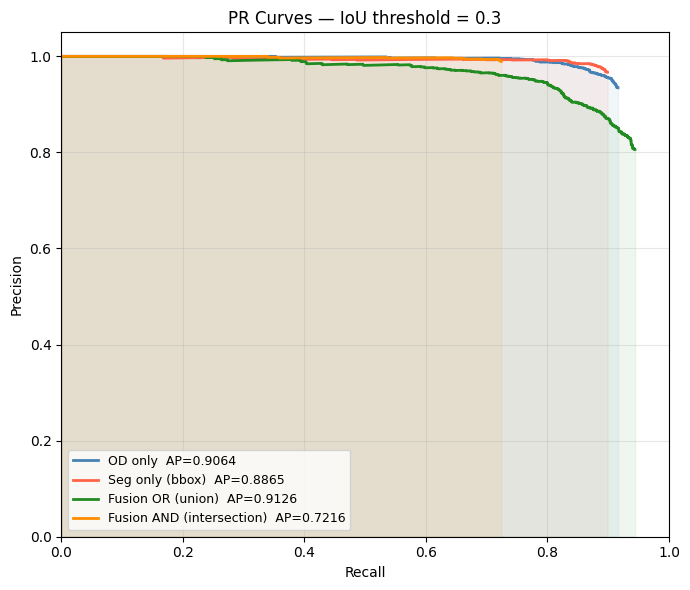

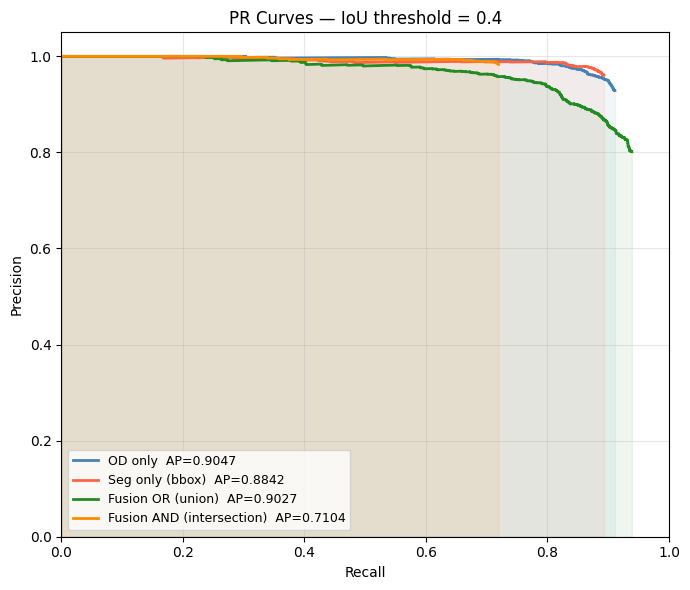

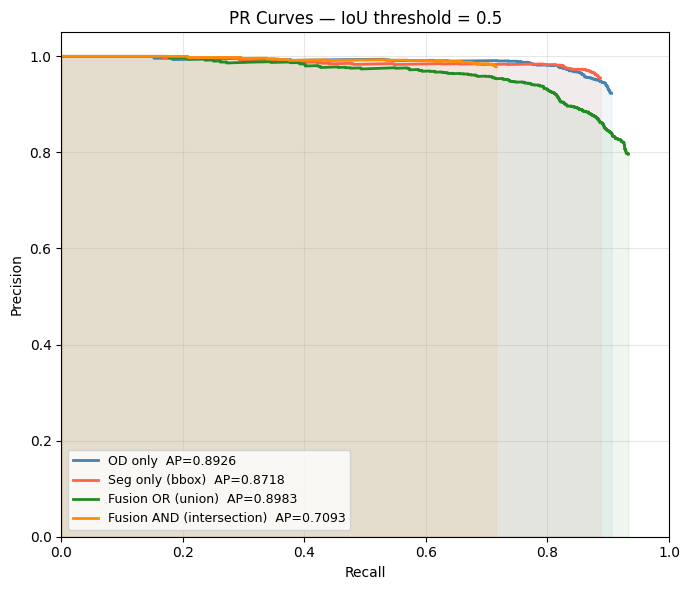

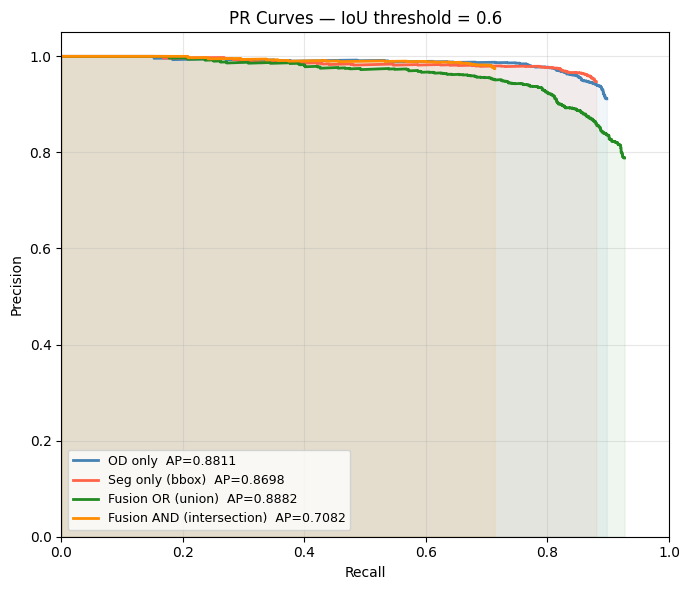

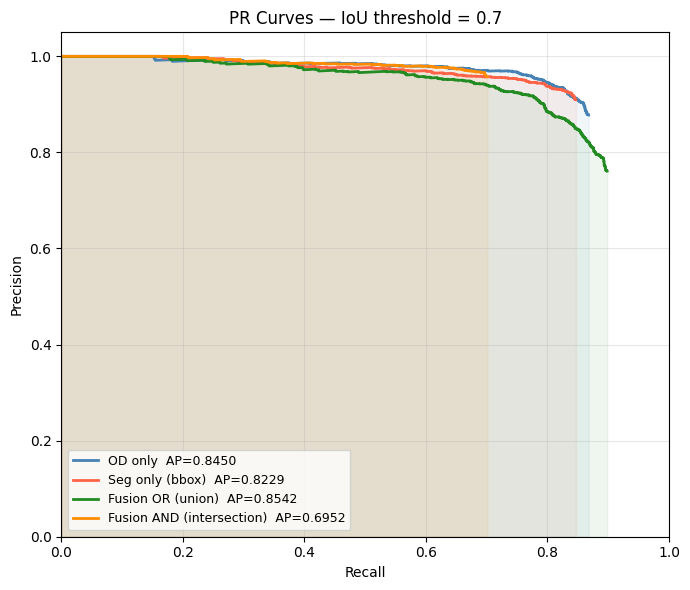

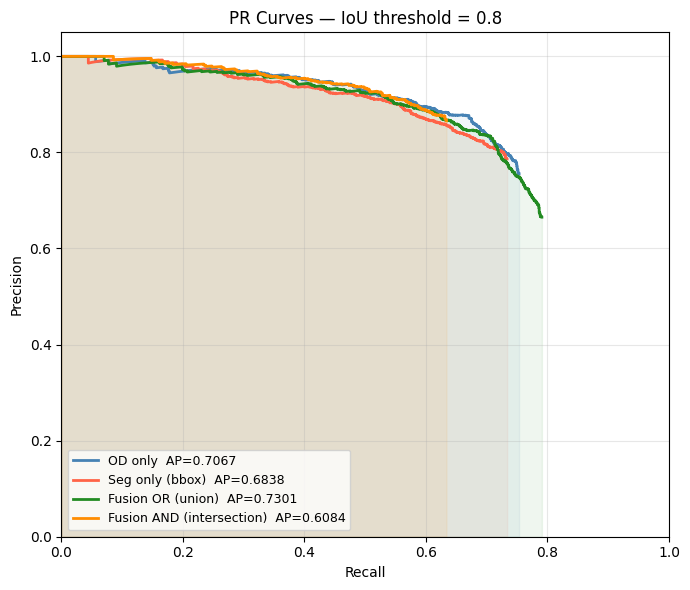

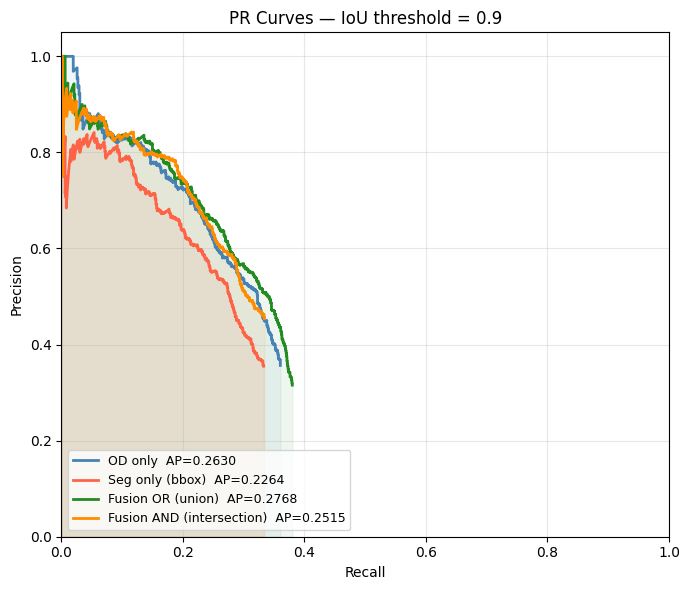

In [89]:
colors = {'od_only': 'steelblue', 'seg_only': 'tomato',
          'or': 'forestgreen', 'and': 'darkorange'}

for iou_threshold in iou_thresholds_report:
    fig, ax = plt.subplots(figsize=(7, 6))
    for strategy in strategies:
        ndf = results_by_strategy_iou[strategy][iou_threshold]
        ap, recalls, precisions = calculate_ap(ndf)
        if len(recalls) == 0:
            continue
        label = f"{strategy_labels[strategy]}  AP={ap:.4f}"
        ax.plot(recalls, precisions, color=colors[strategy], linewidth=2, label=label)
        ax.fill_between(recalls, precisions, alpha=0.07, color=colors[strategy])

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — IoU threshold = {iou_threshold}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [90]:
def visualize_ensemble_samples(od_raw, seg_raw, results_by_strategy_iou,
                                od_root, strategy='or', iou_threshold=0.5,
                                n=16, mode='random', seed=42, show_gt=True):
    """
    每張圖並排顯示 OD-only / Seg-only / Fused 結果。
    mode   : 'random' | 'fp' | 'fn' | 'worst'
    show_gt: True  → 顯示 TP/FP/FN 含 ground truth 框
             False → 只顯示預測框（不含 GT），以信心分數標註
    """
    ndf_fused = results_by_strategy_iou[strategy][iou_threshold]
    grouped   = ndf_fused.groupby('file_name')

    if mode == 'random':
        rng = random.Random(seed)
        file_names = rng.sample(list(grouped.groups.keys()), min(n, len(grouped)))
    else:
        counts = (
            ndf_fused[ndf_fused['match_type'].isin(['FP', 'FN'])]
            .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
        )
        for col in ['FP', 'FN']:
            if col not in counts:
                counts[col] = 0
        if mode == 'fp':
            file_names = counts['FP'].nlargest(n).index.tolist()
        elif mode == 'fn':
            file_names = counts['FN'].nlargest(n).index.tolist()
        else:
            file_names = (counts['FP'] + counts['FN']).nlargest(n).index.tolist()

    # Build filename -> index map
    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    def draw_recs(ax, records):
        for rec in records:
            mt = rec['match_type']
            if show_gt:
                # --- 原本模式：顯示 TP/FP/FN 含 GT 框 ---
                if mt == 'TP':
                    for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                       (rec['gt_box'],   'green', '--')]:
                        if box:
                            ax.add_patch(plt.Rectangle(
                                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                    if rec['pred_box']:
                        ax.text(rec['pred_box'][0], rec['pred_box'][1]-4,
                                f"TP iou={rec['iou']:.2f}", color='lime', fontsize=6)
                elif mt == 'FP':
                    b = rec['pred_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='red', facecolor='none'))
                        ax.text(b[0], b[1]-4, 'FP', color='red', fontsize=6)
                elif mt == 'FN':
                    b = rec['gt_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))
                        ax.text(b[0], b[1]-4, 'FN', color='orange', fontsize=6)
            else:
                # --- 純預測模式：只畫 pred_box，不顯示 GT ---
                if mt in ('TP', 'FP'):
                    b = rec['pred_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='cyan', facecolor='none'))
                        conf = rec.get('conf')
                        label = f"{conf:.2f}" if conf is not None else ''
                        ax.text(b[0], b[1]-4, label, color='cyan', fontsize=6)

    strategy_cols = ['od_only', 'seg_only', strategy]
    col_titles    = ['OD only', 'Seg only', f'Fusion ({strategy})']
    ncols, nrows  = len(strategy_cols), len(file_names)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, fname in enumerate(file_names):
        idx = fname_to_idx.get(fname)
        if idx is None:
            continue
        od_path = od_raw[idx][0]
        img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)

        for col_i, strat in enumerate(strategy_cols):
            ax = axes[row_i, col_i]
            ax.imshow(img)
            recs_df = results_by_strategy_iou[strat][iou_threshold]
            if fname in recs_df['file_name'].values:
                draw_recs(ax, recs_df[recs_df['file_name'] == fname].to_dict('records'))
            if show_gt:
                tp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'TP').sum()
                fp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FP').sum()
                fn = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FN').sum()
                ax.set_title(f"{col_titles[col_i]}\n{fname}\nTP={tp} FP={fp} FN={fn}",
                             fontsize=8)
            else:
                n_pred = (recs_df[recs_df['file_name'] == fname]['match_type']
                          .isin(['TP', 'FP'])).sum()
                ax.set_title(f"{col_titles[col_i]}\n{fname}\npred={n_pred}",
                             fontsize=8)
            ax.axis('off')

    if show_gt:
        legend_elems = [
            mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
            mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
            mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
            mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
        ]
    else:
        legend_elems = [
            mpatches.Patch(edgecolor='cyan', facecolor='none', linestyle='-', label='prediction'),
        ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f"Ensemble comparison  |  IoU={iou_threshold}  |  mode={mode}  |  show_gt={show_gt}",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


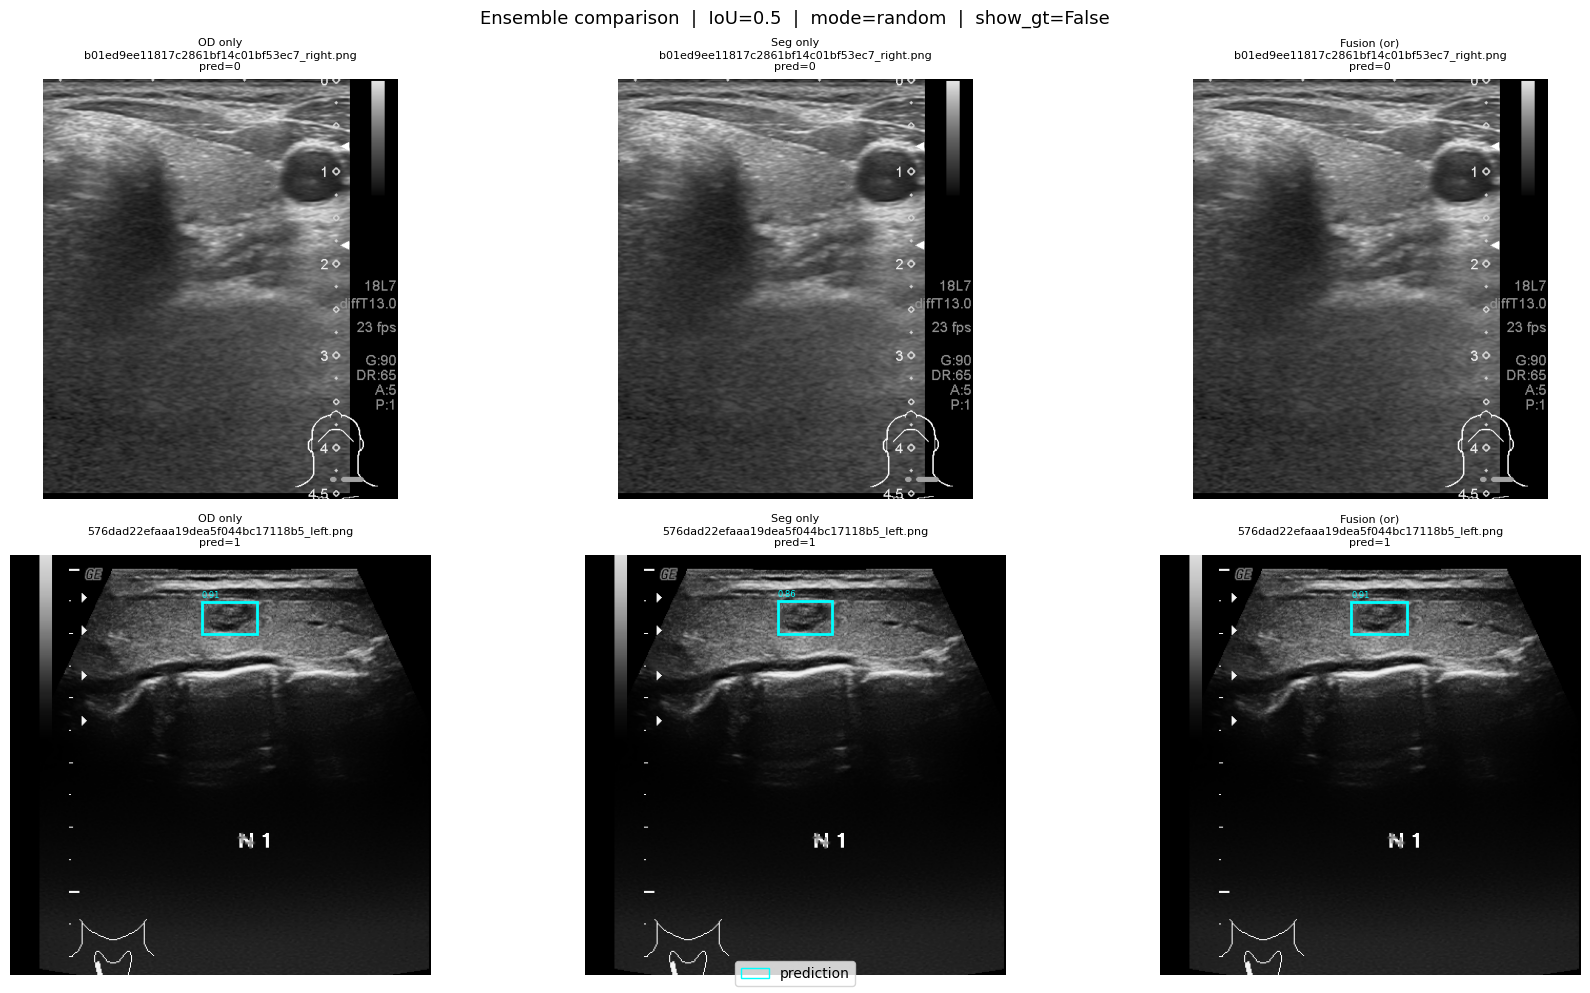

In [91]:
# 調整 mode: 'random' | 'fp' | 'fn' | 'worst'
# 調整 strategy: 'or' | 'and'
# 調整 show_gt: True（含 ground truth）| False（只顯示預測框）

visualize_ensemble_samples(
    od_raw, seg_raw, results_by_strategy_iou,
    od_root=od_root,
    strategy='or',
    iou_threshold=0.5,
    n=2,
    mode='random',
    seed = None,
    show_gt=False,
)


## 結節大小對效能之影響（定性分析）

以各影像 DICOM 的 Pixel Spacing（`SequenceOfUltrasoundRegions.PhysicalDeltaX/Y`）將 GT bounding box 換算為實際大小（mm），
再以固定切點 **6.9 mm / 12.6 mm** 分為 **小 / 中 / 大** 三類，
分析各策略在不同大小結節上的 Recall、Precision、F1 表現。


In [92]:
# ============================================================
# 載入 DICOM Pixel Spacing，建立 file_name → (ps_x_mm, ps_y_mm) 對應表
# ============================================================
import pydicom, subprocess, re
from pathlib import Path

DCM_ROOT = "/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data"

# 收集所有需要查的 file_name
all_fnames = set()
for strategy in strategies:
    for iou_thr in results_by_strategy_iou[strategy]:
        all_fnames.update(results_by_strategy_iou[strategy][iou_thr]["file_name"].unique())

def fname_to_hash(fname):
    stem = Path(fname).stem  # strip extension first
    return re.sub(r"_(left|right)$", "", stem)

unique_hashes = list({fname_to_hash(f) for f in all_fnames})

# 建立 hash → dcm path 索引
result = subprocess.run(["find", DCM_ROOT, "-name", "*.dcm"], capture_output=True, text=True)
all_dcm = [p for p in result.stdout.strip().split("\n") if p]
hash_to_dcm = {Path(p).stem: p for p in all_dcm}
print(f"DCM 索引: {len(hash_to_dcm)} 個檔案")


DCM 索引: 37766 個檔案


In [93]:

def get_pixel_spacing(dcm_path):
    try:
        print(dcm_path)
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        if hasattr(ds, "PixelSpacing"):
            ps = ds.PixelSpacing
            return float(ps[1]), float(ps[0])
        if hasattr(ds, "SequenceOfUltrasoundRegions"):
            for reg in ds.SequenceOfUltrasoundRegions:
                pdx = getattr(reg, "PhysicalDeltaX", None)
                pdy = getattr(reg, "PhysicalDeltaY", None)
                if pdx is not None and pdy is not None:
                    return abs(float(pdx)) * 10, abs(float(pdy)) * 10
    except Exception:
        pass
    return None, None

spacing_map = {}
for h in unique_hashes:
    if h in hash_to_dcm:
        spacing_map[h] = get_pixel_spacing(hash_to_dcm[h])
    else:
        spacing_map[h] = (None, None)

found = sum(1 for v in spacing_map.values() if v[0] is not None)
print(f"成功讀取 pixel spacing: {found}/{len(unique_hashes)}")


/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data_for_future/B18C03F8180ED97F71BF1ADBF51205862A755D0E/97F182464A58DE52D4ABFFABE51B9A367A746AF1/dc4bdfd73093755c2a0d84a922c39b42.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/C4B6E56EEC75B1074A081070DD373ABA5ED80F18/4EFA9E76B37E3DD3684E43E52596857CCAF065A9/57c9aee2488e5370b4a23434a0c9f343.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/4F81C239A5ACB41CFECEDC95A623C1D4C1054580/664969BD754E9EE8582B923F01AA12BB2CE1F20C/f7f0d8ddc14907b25e2735f893233427.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/81564519A7C0C4FB1682444F55A1EDB1C810DCA5/5EB8826FB11C7E0A0F7D186649C12F3A740E29B7/19d44882f8c33fa239759c8651f6e31a.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/03831E00BFA4B612CB8EAFCA2B1D371AC63E5C1C/FC42E09CBAF945B55A31D73CF207C4AB0AE791B1/05db9eac968cf0a749450728e29dbd0e.dcm
/Users/tony.tu/Desktop/戴承智慧/t

In [94]:

# file_name → (ps_x_mm, ps_y_mm)
file_to_spacing = {f: spacing_map[fname_to_hash(f)] for f in all_fnames}

# ── 統計沒有 spacing 資訊的影像數 ──────────────────────────────
no_dcm       = [h for h, v in spacing_map.items() if h not in hash_to_dcm]
dcm_no_space = [h for h, v in spacing_map.items() if h in hash_to_dcm and v[0] is None]
has_space    = [h for h, v in spacing_map.items() if v[0] is not None]

total_imgs       = len(all_fnames)
imgs_no_spacing  = sum(1 for f in all_fnames if file_to_spacing[f][0] is None)
imgs_has_spacing = total_imgs - imgs_no_spacing

print(f"[Pixel Spacing 統計]")
print(f"  總影像數 (file_name):         {total_imgs}")
print(f"  有 spacing 影像數:            {imgs_has_spacing} ({imgs_has_spacing/total_imgs*100:.1f}%)")
print(f"  無 spacing 影像數:            {imgs_no_spacing} ({imgs_no_spacing/total_imgs*100:.1f}%)")
print(f"    ├ 找不到 DCM 檔 (hash):     {len(no_dcm)}")
print(f"    └ DCM 存在但讀不到 spacing: {len(dcm_no_space)}")


# ============================================================
# 結節大小分類設定（固定切點 6.9 / 12.6 mm）
# ============================================================

SIZE_ANALYSIS_IOU = 0.5
Q33_MM = 6.9
Q67_MM = 12.6

SIZE_LABELS = [
    f"Small\n(<{Q33_MM} mm)",
    f"Medium\n({Q33_MM}\u2013{Q67_MM} mm)",
    f"Large\n(\u2265{Q67_MM} mm)",
]

def get_gt_max_dim_mm(box, fname):
    if box is None:
        return None
    ps = file_to_spacing.get(fname, (None, None))
    if ps[0] is None:
        return None
    x1, y1, x2, y2 = box
    w_mm = max(0, x2 - x1) * ps[0]
    h_mm = max(0, y2 - y1) * ps[1]
    return max(w_mm, h_mm)

def size_category(dim_mm):
    if dim_mm is None or (isinstance(dim_mm, float) and np.isnan(dim_mm)):
        return None
    if dim_mm < Q33_MM:
        return SIZE_LABELS[0]
    elif dim_mm < Q67_MM:
        return SIZE_LABELS[1]
    else:
        return SIZE_LABELS[2]

# 統計 OR/IoU=0.5 的 GT 結節 mm 分佈（供直方圖使用）
ref_df = results_by_strategy_iou["or"][SIZE_ANALYSIS_IOU].copy()
ref_gt = ref_df[ref_df["match_type"].isin(["TP", "FN"])].copy()
ref_gt["gt_max_dim_mm"] = ref_gt.apply(
    lambda r: get_gt_max_dim_mm(r["gt_box"], r["file_name"]), axis=1)
ref_dims = ref_gt["gt_max_dim_mm"].dropna()

print(f"\nGT 結節實際大小分佈（Fusion OR, IoU=0.5，有 spacing 資料者）")
print(f"  N        : {len(ref_dims)}")
print(f"  Min      : {ref_dims.min():.2f} mm")
print(f"  Q33 切點  : {Q33_MM} mm  (小/中 分界)")
print(f"  Median   : {ref_dims.median():.2f} mm")
print(f"  Q67 切點  : {Q67_MM} mm  (中/大 分界)")
print(f"  Max      : {ref_dims.max():.2f} mm")


[Pixel Spacing 統計]
  總影像數 (file_name):         2364
  有 spacing 影像數:            2156 (91.2%)
  無 spacing 影像數:            208 (8.8%)
    ├ 找不到 DCM 檔 (hash):     0
    └ DCM 存在但讀不到 spacing: 149

GT 結節實際大小分佈（Fusion OR, IoU=0.5，有 spacing 資料者）
  N        : 1530
  Min      : 2.48 mm
  Q33 切點  : 6.9 mm  (小/中 分界)
  Median   : 9.79 mm
  Q67 切點  : 12.6 mm  (中/大 分界)
  Max      : 51.24 mm


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/3680458613.py:37: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/3680458613.py:37: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/3680458613.py:37: UserWarning: Glyph 37002 (\N{CJK UNIFIED IDEOGRAPH-908A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/3680458613.py:37: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/3680458613.py:37: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

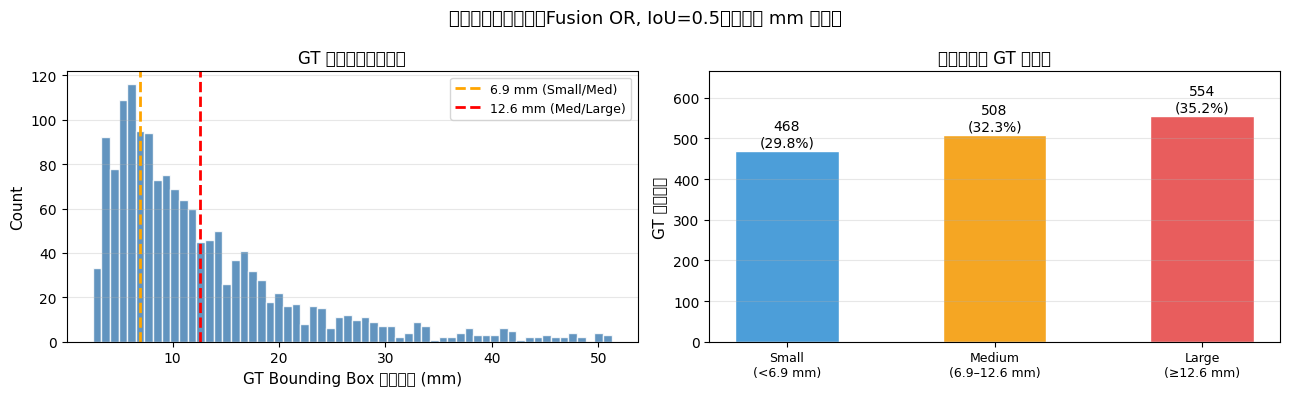

In [95]:
# ============================================================
# 結節大小（mm）分佈直方圖 + 大小分組佔比
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：mm 直方圖
ax = axes[0]
ax.hist(ref_dims, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(Q33_MM, color="orange", linewidth=2, linestyle="--", label=f"6.9 mm (Small/Med)")
ax.axvline(Q67_MM, color="red",    linewidth=2, linestyle="--", label=f"12.6 mm (Med/Large)")
ax.set_xlabel("GT Bounding Box 最大邊長 (mm)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("GT 結節實際大小分佈", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# 右：各大小分組 GT 數量
ref_gt["size_cat"] = ref_gt["gt_max_dim_mm"].apply(size_category)
cat_counts = ref_gt["size_cat"].value_counts().reindex(SIZE_LABELS).fillna(0)

ax2 = axes[1]
bars = ax2.bar(range(len(SIZE_LABELS)), cat_counts.values,
               color=["#4C9ED9", "#F5A623", "#E85D5D"], edgecolor="white", width=0.5)
for bar, val in zip(bars, cat_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{int(val)}\n({int(val)/len(ref_gt)*100:.1f}%)",
             ha="center", va="bottom", fontsize=10)
ax2.set_xticks(range(len(SIZE_LABELS)))
ax2.set_xticklabels(SIZE_LABELS, fontsize=9)
ax2.set_ylabel("GT 結節數量", fontsize=11)
ax2.set_title("各大小分組 GT 結節數", fontsize=12)
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(0, cat_counts.max() * 1.2)

plt.suptitle("結節大小分佈概覽（Fusion OR, IoU=0.5，以實際 mm 分類）", fontsize=13)
plt.tight_layout()
plt.show()


In [96]:
# ============================================================
# 各策略 × 結節大小（mm）→ TP/FP/FN 計數 & 指標
# ============================================================

size_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][SIZE_ANALYSIS_IOU].copy()

    # TP / FN → GT box mm；FP → pred box mm
    df["gt_max_dim_mm"] = df.apply(
        lambda r: get_gt_max_dim_mm(r["gt_box"], r["file_name"]), axis=1)
    fp_mask = df["match_type"] == "FP"
    df.loc[fp_mask, "gt_max_dim_mm"] = df.loc[fp_mask].apply(
        lambda r: get_gt_max_dim_mm(r["pred_box"], r["file_name"]), axis=1)

    df["size_cat"] = df["gt_max_dim_mm"].apply(size_category)
    df = df.dropna(subset=["size_cat"])

    for sc in SIZE_LABELS:
        sub = df[df["size_cat"] == sc]
        tp = (sub["match_type"] == "TP").sum()
        fp = (sub["match_type"] == "FP").sum()
        fn = (sub["match_type"] == "FN").sum()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = sub.loc[sub["match_type"] == "TP", "iou"].dropna()
        size_records.append({
            "strategy":  strategy,
            "label":     strategy_labels[strategy],
            "size_cat":  sc,
            "TP": tp, "FP": fp, "FN": fn,
            "recall":    recall,
            "precision": precision,
            "f1":        f1,
            "mean_iou":  tp_iou.mean() if len(tp_iou) else np.nan,
        })

size_df = pd.DataFrame(size_records)

pivot_f1     = size_df.pivot_table(index="label", columns="size_cat", values="f1",        aggfunc="first")[SIZE_LABELS]
pivot_recall = size_df.pivot_table(index="label", columns="size_cat", values="recall",    aggfunc="first")[SIZE_LABELS]
pivot_prec   = size_df.pivot_table(index="label", columns="size_cat", values="precision", aggfunc="first")[SIZE_LABELS]

print("=== F1 by Nodule Size (IoU=0.5, mm-based) ===")
display(pivot_f1.round(4))
print("\n=== Recall by Nodule Size ===")
display(pivot_recall.round(4))
print("\n=== Precision by Nodule Size ===")
display(pivot_prec.round(4))


=== F1 by Nodule Size (IoU=0.5, mm-based) ===


size_cat,Small\n(<6.9 mm),Medium\n(6.9–12.6 mm),Large\n(≥12.6 mm)
label,,,
Fusion AND (intersection),0.7440,0.8447,0.8814
Fusion OR (union),0.8187,0.8676,0.8908
OD only,0.9160,0.9152,0.9112
Seg only (bbox),0.9132,0.9206,0.9229



=== Recall by Nodule Size ===


size_cat,Small\n(<6.9 mm),Medium\n(6.9–12.6 mm),Large\n(≥12.6 mm)
label,,,
Fusion AND (intersection),0.5962,0.7441,0.8051
Fusion OR (union),0.9167,0.9350,0.9422
OD only,0.8974,0.9134,0.9079
Seg only (bbox),0.8547,0.8898,0.9079



=== Precision by Nodule Size ===


size_cat,Small\n(<6.9 mm),Medium\n(6.9–12.6 mm),Large\n(≥12.6 mm)
label,,,
Fusion AND (intersection),0.9894,0.9767,0.9738
Fusion OR (union),0.7397,0.8092,0.8447
OD only,0.9354,0.9170,0.9145
Seg only (bbox),0.9804,0.9536,0.9384


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2930694873.py:37: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2930694873.py:37: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2930694873.py:37: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2930694873.py:37: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2930694873.py:37: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

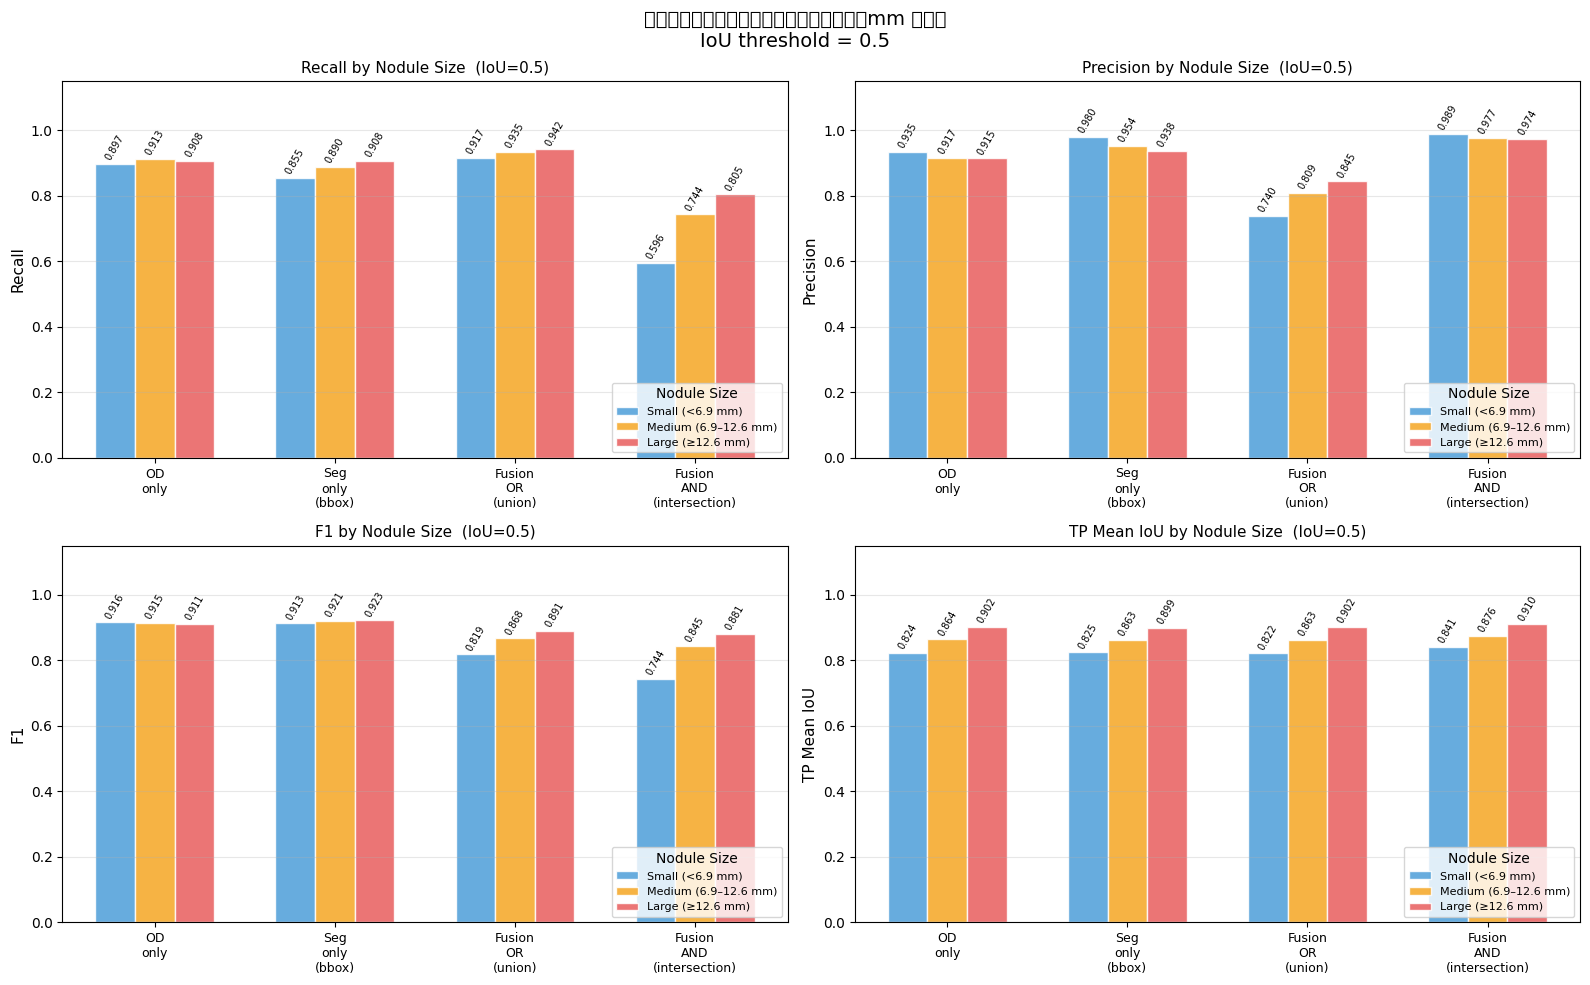

In [97]:
# ============================================================
# 視覺化：各策略 × 大小分組 的 Recall / Precision / F1 / TP-IoU
# ============================================================

metrics_to_plot = ['recall', 'precision', 'f1', 'mean_iou']
metric_titles   = ['Recall', 'Precision', 'F1', 'TP Mean IoU']
size_colors     = ['#4C9ED9', '#F5A623', '#E85D5D']   # small / medium / large

x      = np.arange(len(strategies))
width  = 0.22

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric, title in zip(axes.flat, metrics_to_plot, metric_titles):
    for si, sc in enumerate(SIZE_LABELS):
        vals = []
        for strategy in strategies:
            row = size_df[(size_df['strategy'] == strategy) & (size_df['size_cat'] == sc)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else 0)
        offset = (si - 1) * width
        bars = ax.bar(x + offset, vals, width, label=sc.replace('\n', ' '),
                      color=size_colors[si], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=60)

    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n') for s in strategies], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Nodule Size  (IoU={SIZE_ANALYSIS_IOU})', fontsize=11)
    ax.legend(title='Nodule Size', fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('結節大小對各策略效能之影響（定性分析，mm 分類）\nIoU threshold = 0.5', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1915546100.py:38: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1915546100.py:38: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1915546100.py:38: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1915546100.py:38: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1915546100.py:38: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

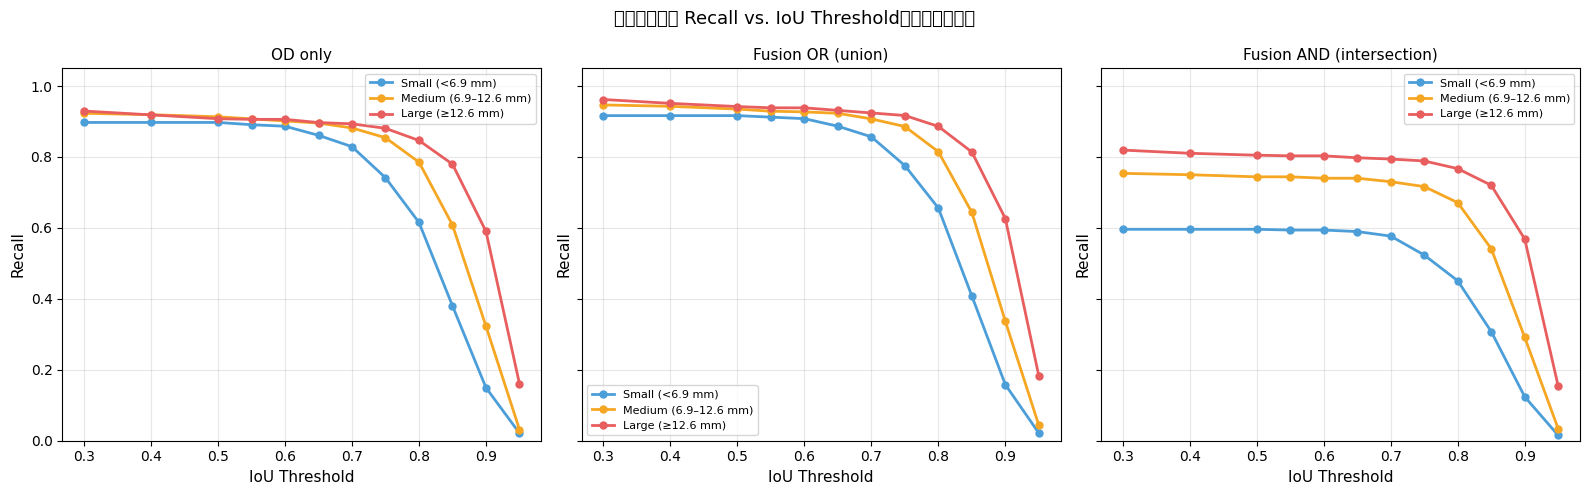

In [98]:
# ============================================================
# 跨 IoU 閾值分析：各大小類別的 Recall 趨勢（以 OR 策略為例）
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
iou_sweep = iou_thresholds_report   # [0.3, 0.5, 0.7]

# 改用連續的 IoU 值呈現趨勢
iou_sweep_full = all_iou_thresholds   # 全部評估過的閾值

for ax, strategy in zip(axes, ['od_only', 'or', 'and']):
    for si, sc in enumerate(SIZE_LABELS):
        recalls = []
        for iou_thr_val in iou_sweep_full:
            df_iou = results_by_strategy_iou[strategy][iou_thr_val].copy()
            df_iou['gt_max_dim_mm'] = df_iou.apply(
                lambda r: get_gt_max_dim_mm(r['gt_box'], r['file_name']), axis=1)
            fp_m = df_iou['match_type'] == 'FP'
            df_iou.loc[fp_m, 'gt_max_dim_mm'] = df_iou.loc[fp_m].apply(
                lambda r: get_gt_max_dim_mm(r['pred_box'], r['file_name']), axis=1)
            df_iou['size_cat'] = df_iou['gt_max_dim_mm'].apply(size_category)
            sub = df_iou[df_iou['size_cat'] == sc]
            tp = (sub['match_type'] == 'TP').sum()
            fn = (sub['match_type'] == 'FN').sum()
            recall, _, _ = compute_metrics_from_counts(tp, 0, fn)
            recalls.append(recall)
        ax.plot(iou_sweep_full, recalls, marker='o', markersize=5,
                color=size_colors[si], linewidth=2,
                label=sc.replace('\n', ' '))
    ax.set_xlabel('IoU Threshold', fontsize=11)
    ax.set_ylabel('Recall', fontsize=11)
    ax.set_title(f'{strategy_labels[strategy]}', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('各結節大小的 Recall vs. IoU Threshold（跨策略比較）', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1068648957.py:89: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1068648957.py:89: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1068648957.py:89: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1068648957.py:89: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1068648957.py:89: UserWarning: Glyph 27171 (\N{CJK UNIFIED IDEOGRAPH-6A23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

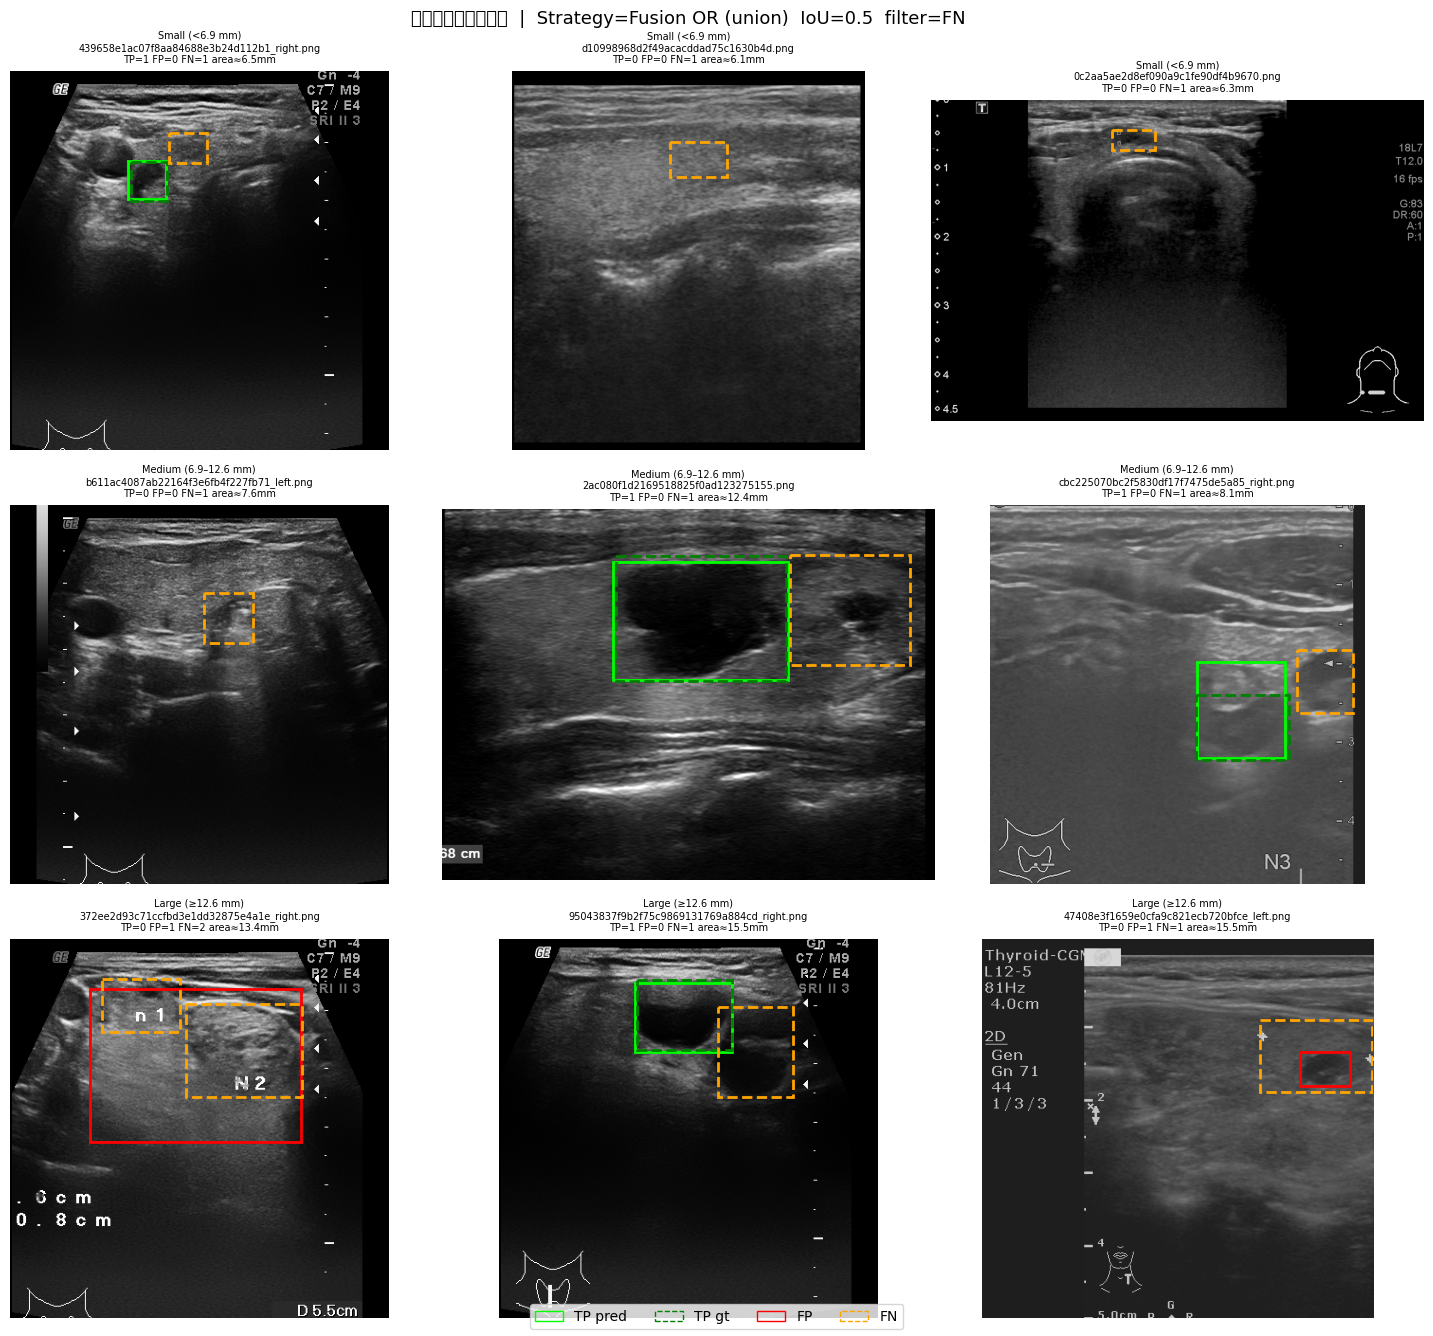

In [99]:
# ============================================================
# 樣本視覺化：每個大小分組各取 N 個 FN（漏偵）和 TP 案例
# ============================================================

def visualize_by_size(od_raw, seg_raw, results_by_strategy_iou,
                      strategy='or', iou_threshold=0.5,
                      n_per_cat=3, match_type_filter='FN', seed=42):
    """
    按結節大小分組，從指定 match_type（FN 或 TP）中各抽樣 n_per_cat 張圖顯示。
    """
    rng = random.Random(seed)
    df = results_by_strategy_iou[strategy][iou_threshold].copy()
    df['gt_max_dim_mm'] = df.apply(
        lambda r: get_gt_max_dim_mm(r['gt_box'], r['file_name']), axis=1)
    fp_m = df['match_type'] == 'FP'
    df.loc[fp_m, 'gt_max_dim_mm'] = df.loc[fp_m].apply(
        lambda r: get_gt_max_dim_mm(r['pred_box'], r['file_name']), axis=1)
    df['size_cat'] = df['gt_max_dim_mm'].apply(size_category)

    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    nrows = len(SIZE_LABELS)
    ncols = n_per_cat
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, sc in enumerate(SIZE_LABELS):
        sub = df[(df['size_cat'] == sc) & (df['match_type'] == match_type_filter)]
        fnames = sub['file_name'].unique().tolist()
        fnames = rng.sample(fnames, min(n_per_cat, len(fnames)))

        for col_i in range(ncols):
            ax = axes[row_i, col_i]
            ax.axis('off')
            if col_i >= len(fnames):
                continue
            fname = fnames[col_i]
            idx = fname_to_idx.get(fname)
            if idx is None:
                continue
            od_path = od_raw[idx][0]
            img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)

            recs = df[df['file_name'] == fname].to_dict('records')
            for rec in recs:
                mt = rec['match_type']
                if mt == 'TP':
                    for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                       (rec['gt_box'],   'green', '--')]:
                        if box:
                            ax.add_patch(plt.Rectangle(
                                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                elif mt == 'FP':
                    b = rec['pred_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='red', facecolor='none'))
                elif mt == 'FN':
                    b = rec['gt_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))

            tp = sum(1 for r in recs if r['match_type'] == 'TP')
            fp = sum(1 for r in recs if r['match_type'] == 'FP')
            fn = sum(1 for r in recs if r['match_type'] == 'FN')
            dim_val = sub[sub['file_name'] == fname]['gt_max_dim_mm'].values
            area_str = f"{dim_val[0]:.1f}mm" if len(dim_val) > 0 else ''
            ax.set_title(f"{sc.replace(chr(10), ' ')}\n{fname}\nTP={tp} FP={fp} FN={fn} area≈{area_str}",
                         fontsize=7)

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(
        f'結節大小樣本視覺化  |  Strategy={strategy_labels[strategy]}  '
        f'IoU={iou_threshold}  filter={match_type_filter}',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

# FN（漏偵）樣本：最能體現小結節偵測困難
visualize_by_size(od_raw, seg_raw, results_by_strategy_iou,
                  strategy='or', iou_threshold=0.5,
                  n_per_cat=3, match_type_filter='FN')

## 結節數量對效能之影響

以每張影像的 GT 結節數（1, 2, 3, … 顆）分組，分析各策略的 Recall、Precision、F1 表現。

In [100]:
# ============================================================
# 每張影像 GT 結節數 → 效能分析
# ============================================================

NODULE_COUNT_IOU = 0.5   # 分析用的 IoU 閾值
MAX_NODULE_SHOW  = 7     # 超過此數量的影像合併為 "≥N"

def get_gt_nodule_count_per_image(df):
    """計算每張影像的 GT 結節數（TP + FN）。"""
    counts = (
        df[df['match_type'].isin(['TP', 'FN'])]
        .groupby('file_name').size()
    )
    # TN（無 GT、無預測）的影像設為 0，排除已在 counts 中的 file_name
    tn_files = df[df['match_type'] == 'TN']['file_name'].unique()
    tn_files = [f for f in tn_files if f not in counts.index]
    tn_series = pd.Series(0, index=tn_files)
    return pd.concat([counts, tn_series])


# 以 OR 策略建立 file_name → GT 結節數 的對應表（所有策略共用同一 GT）
ref_df_cnt = results_by_strategy_iou['or'][NODULE_COUNT_IOU]
gt_count_map = get_gt_nodule_count_per_image(ref_df_cnt)

# 結節數分佈
count_dist = gt_count_map.value_counts().sort_index()
print("每張影像 GT 結節數分佈：")
print(count_dist.to_string())
print(f"\nTotal images: {len(gt_count_map)}")

每張影像 GT 結節數分佈：
0     883
1    1327
2     102
3      14

Total images: 2326


In [101]:
results_by_strategy_iou[strategy][NODULE_COUNT_IOU]

,patient_ID,file_name,match_type,pred_box,gt_box,iou,conf,center_distance,source
0,5361EE8C3C1F32805CF7DCD382C3BBF132CEBF26,d391e75a9b981397e84339c885c864da_left.png,TP,"[167.17670440673828, 38.64485549926758, 349.98...","[168.00000000000003, 38.99999999999999, 335.0,...",0.875522,0.930796,7.365108,both
1,5361EE8C3C1F32805CF7DCD382C3BBF132CEBF26,d391e75a9b981397e84339c885c864da_right.png,TP,"[89.63181686401367, 39.86842346191406, 245.657...","[94.0, 38.99999999999999, 251.00000000000003, ...",0.893860,0.929597,5.682450,both
2,63597A7850B0966D88F466C755AB523C988F09B7,c987dafe0bbd44b4ee4de353d7ddeb32_left.png,FN,None,"[264.000256, 125.00013399999999, 299.000064, 1...",0.000000,NaN,NaN,None
3,63597A7850B0966D88F466C755AB523C988F09B7,c987dafe0bbd44b4ee4de353d7ddeb32_right.png,TP,"[312.36962890625, 120.13383865356445, 364.3011...","[312.0, 117.999882, 367.00006399999995, 149.99...",0.860687,0.850707,1.368551,both
4,CD713E603F7655DDC1803C1A9DD7CB7E2728E765,93effacee0f8749285b35bacfdd9f2e6_left.png,TP,"[142.5849380493164, 38.0302619934082, 263.3522...","[144.0, 37.00000000000001, 272.0, 95.0]",0.899893,0.885887,5.041570,both
...,...,...,...,...,...,...,...,...,...
2512,563A9D53F301E21115802A01BBA930E6AB2AC5E2,7551ffe32b65208b2e52442ef55ed767_left.png,TN,None,None,NaN,NaN,NaN,None
2513,0A2439C3D54EC10A2C1B2BC5C4113ABF4536F35B,27f5efada664aa4858a8bced66b88b54.png,TN,None,None,NaN,NaN,NaN,None
2514,0A2439C3D54EC10A2C1B2BC5C4113ABF4536F35B,6fe5790e414a7f7cdd28c458e944a271.png,TN,None,None,NaN,NaN,NaN,None
2515,0A2439C3D54EC10A2C1B2BC5C4113ABF4536F35B,42eba5aa053b492b9e6f7bb781a058f3.png,TN,None,None,NaN,NaN,NaN,None


In [102]:
# ============================================================
# 各策略 × 結節數量 → TP/FP/FN 計數 & 指標
# ============================================================

def nodule_count_label(n, max_show=MAX_NODULE_SHOW):
    if n >= max_show:
        return f'≥{max_show}'
    return str(int(n))

nodule_count_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][NODULE_COUNT_IOU].copy()
    df['gt_nodule_count'] = df['file_name'].map(gt_count_map)

    for cnt_val, grp in df.groupby('gt_nodule_count'):
        label = nodule_count_label(cnt_val)
        tp = (grp['match_type'] == 'TP').sum()
        fp = (grp['match_type'] == 'FP').sum()
        fn = (grp['match_type'] == 'FN').sum()
        n_images = grp['file_name'].nunique()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = grp.loc[grp['match_type'] == 'TP', 'iou'].dropna()
        nodule_count_records.append({
            'strategy':      strategy,
            'label':         strategy_labels[strategy],
            'nodule_count':  cnt_val,
            'count_label':   label,
            'n_images':      n_images,
            'TP': tp, 'FP': fp, 'FN': fn,
            'recall':        recall,
            'precision':     precision,
            'f1':            f1,
            'mean_iou':      tp_iou.mean() if len(tp_iou) else np.nan,
        })

cnt_df = pd.DataFrame(nodule_count_records)

# ---- 建立顯示用的 label 順序（1,2,3,...,≥N）
raw_counts = sorted(cnt_df['nodule_count'].unique())
label_order = [nodule_count_label(c) for c in raw_counts]
label_order = list(dict.fromkeys(label_order))   # 去重且保序

# ---- 樞紐表：F1
pivot_f1_cnt = cnt_df.pivot_table(
    index='label', columns='count_label', values='f1', aggfunc='first'
).reindex(columns=label_order)
pivot_recall_cnt = cnt_df.pivot_table(
    index='label', columns='count_label', values='recall', aggfunc='first'
).reindex(columns=label_order)
pivot_prec_cnt = cnt_df.pivot_table(
    index='label', columns='count_label', values='precision', aggfunc='first'
).reindex(columns=label_order)

print(f"=== F1 by Nodule Count per Image (IoU={NODULE_COUNT_IOU}) ===")
display(pivot_f1_cnt.round(4))
print(f"\n=== Recall by Nodule Count ===")
display(pivot_recall_cnt.round(4))
print(f"\n=== Precision by Nodule Count ===")
display(pivot_prec_cnt.round(4))

# 影像數量分佈（只印一次）
n_img_per_cnt = cnt_df[cnt_df['strategy'] == 'or'][['count_label', 'n_images']].set_index('count_label').reindex(label_order)
print(f"\n影像數量 per 結節數：")
display(n_img_per_cnt.T)

=== F1 by Nodule Count per Image (IoU=0.5) ===


count_label,0,1,2,3
label,,,,
Fusion AND (intersection),0.0,0.8562,0.6623,0.5263
Fusion OR (union),0.0,0.8838,0.8041,0.6957
OD only,0.0,0.9398,0.8421,0.6769
Seg only (bbox),0.0,0.9526,0.7706,0.5902



=== Recall by Nodule Count ===


count_label,0,1,2,3
label,,,,
Fusion AND (intersection),0.0,0.7604,0.5000,0.3571
Fusion OR (union),0.0,0.9691,0.7745,0.5714
OD only,0.0,0.9420,0.7451,0.5238
Seg only (bbox),0.0,0.9397,0.6422,0.4286



=== Precision by Nodule Count ===


count_label,0,1,2,3
label,,,,
Fusion AND (intersection),0.0,0.9796,0.9808,1.0000
Fusion OR (union),0.0,0.8124,0.8360,0.8889
OD only,0.0,0.9377,0.9682,0.9565
Seg only (bbox),0.0,0.9659,0.9632,0.9474



影像數量 per 結節數：


count_label,0,1,2,3
n_images,883,1327,102,14


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2383944247.py:39: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2383944247.py:39: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2383944247.py:39: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2383944247.py:39: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2383944247.py:39: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

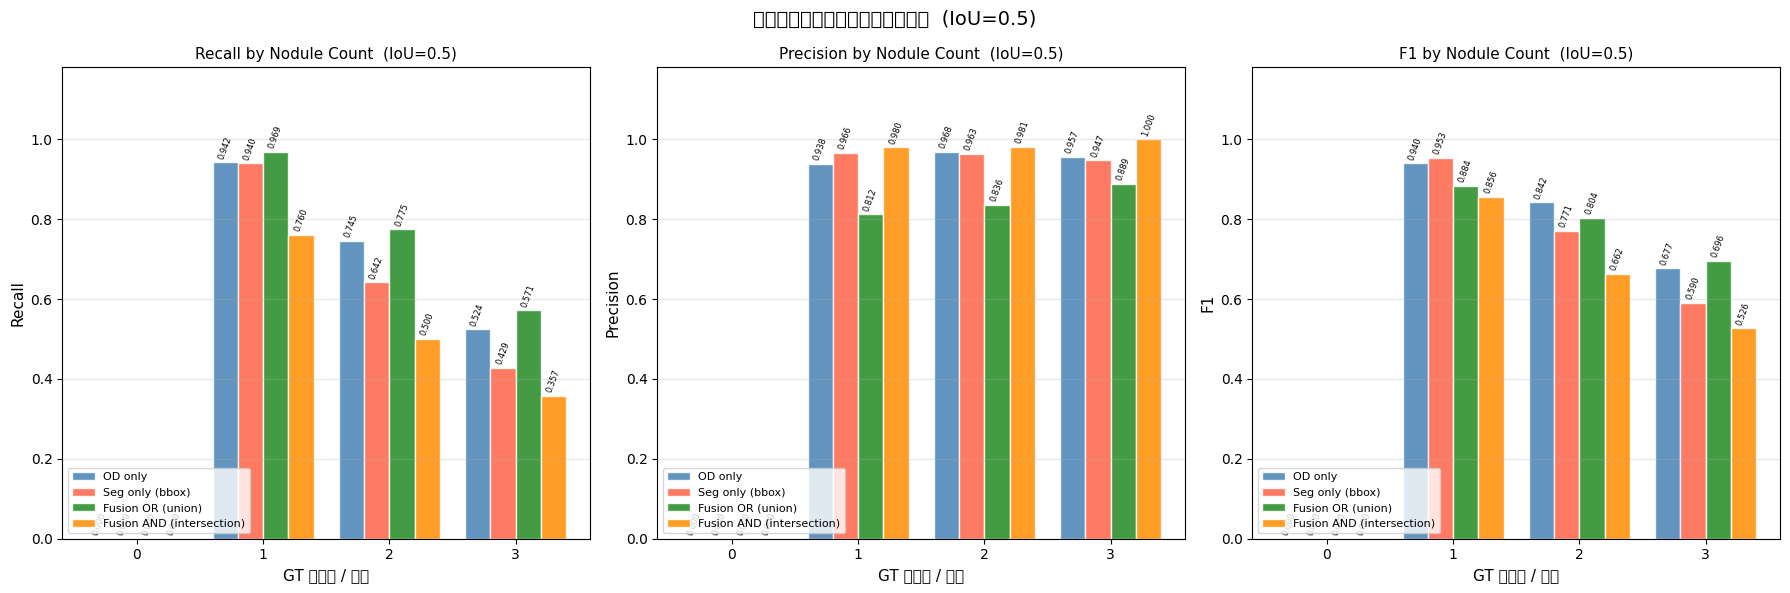

In [103]:
# ============================================================
# 視覺化：各策略 × 結節數量 → Recall / Precision / F1
# ============================================================

metrics_cnt = ['recall', 'precision', 'f1']
metric_titles_cnt = ['Recall', 'Precision', 'F1']

x_pos = np.arange(len(label_order))
width_cnt = 0.2
strat_colors = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, metric, title in zip(axes, metrics_cnt, metric_titles_cnt):
    for si, strategy in enumerate(strategies):
        vals = []
        for lbl in label_order:
            row = cnt_df[(cnt_df['strategy'] == strategy) & (cnt_df['count_label'] == lbl)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else np.nan)
        offset = (si - 1.5) * width_cnt
        bars = ax.bar(x_pos + offset, vals, width_cnt,
                      label=strategy_labels[strategy],
                      color=strat_colors[si], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=70)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(label_order, fontsize=10)
    ax.set_xlabel('GT 結節數 / 影像', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Nodule Count  (IoU={NODULE_COUNT_IOU})', fontsize=11)
    ax.set_ylim(0, 1.18)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'不同結節數量對各策略效能之影響  (IoU={NODULE_COUNT_IOU})', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1937305573.py:30: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1937305573.py:30: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1937305573.py:30: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1937305573.py:30: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1937305573.py:30: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

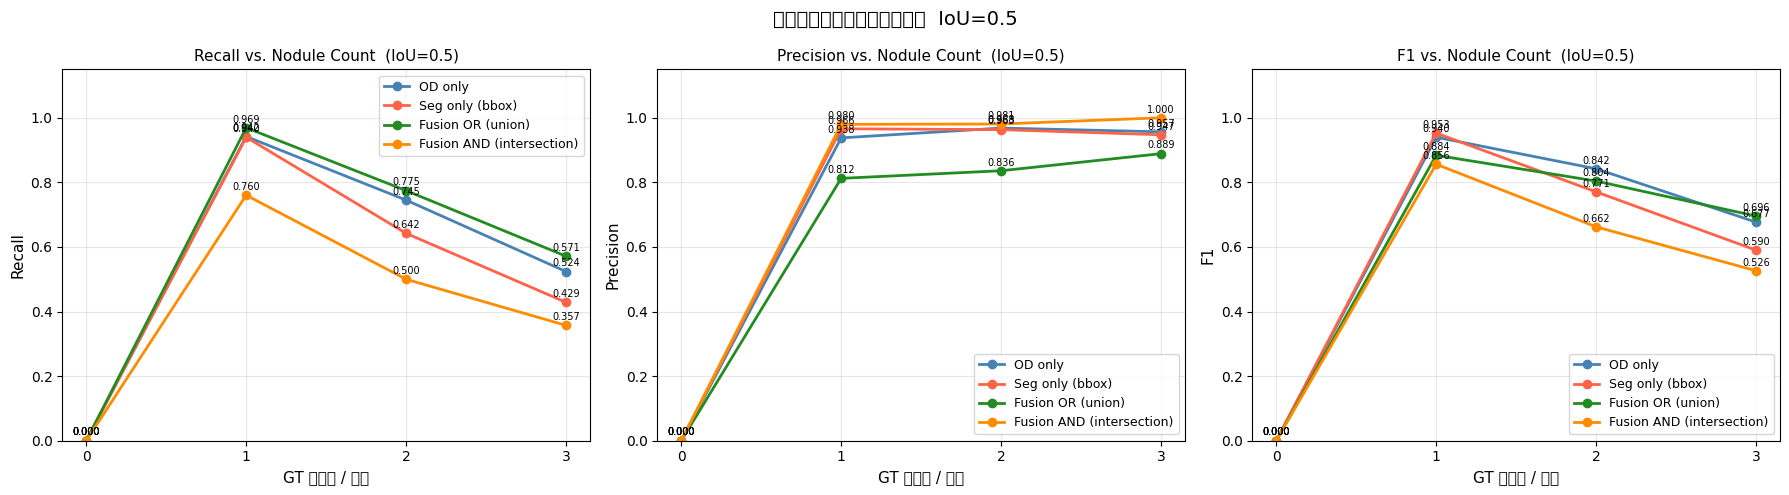

In [104]:
# ============================================================
# 折線圖：以 OR 策略為主，Recall/Precision/F1 vs. 結節數
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes, metrics_cnt, metric_titles_cnt):
    for si, strategy in enumerate(strategies):
        sub = cnt_df[cnt_df['strategy'] == strategy].copy()
        # 按原始數值排序後取對應 label_order 的值
        sub = sub.sort_values('nodule_count')
        # 合併 ≥N 的多個 row（若有）
        sub_grouped = sub.groupby('count_label', sort=False)[metric].mean().reindex(label_order)
        vals = sub_grouped.values
        ax.plot(label_order, vals, marker='o', markersize=6,
                color=strat_colors[si], linewidth=2,
                label=strategy_labels[strategy])
        for xi, v in enumerate(vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('GT 結節數 / 影像', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs. Nodule Count  (IoU={NODULE_COUNT_IOU})', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'結節數量趨勢分析（折線圖）  IoU={NODULE_COUNT_IOU}', fontsize=14)
plt.tight_layout()
plt.show()

### Visualization: Poor-performing Cases in Multi-Nodule Images (Missed Detections)

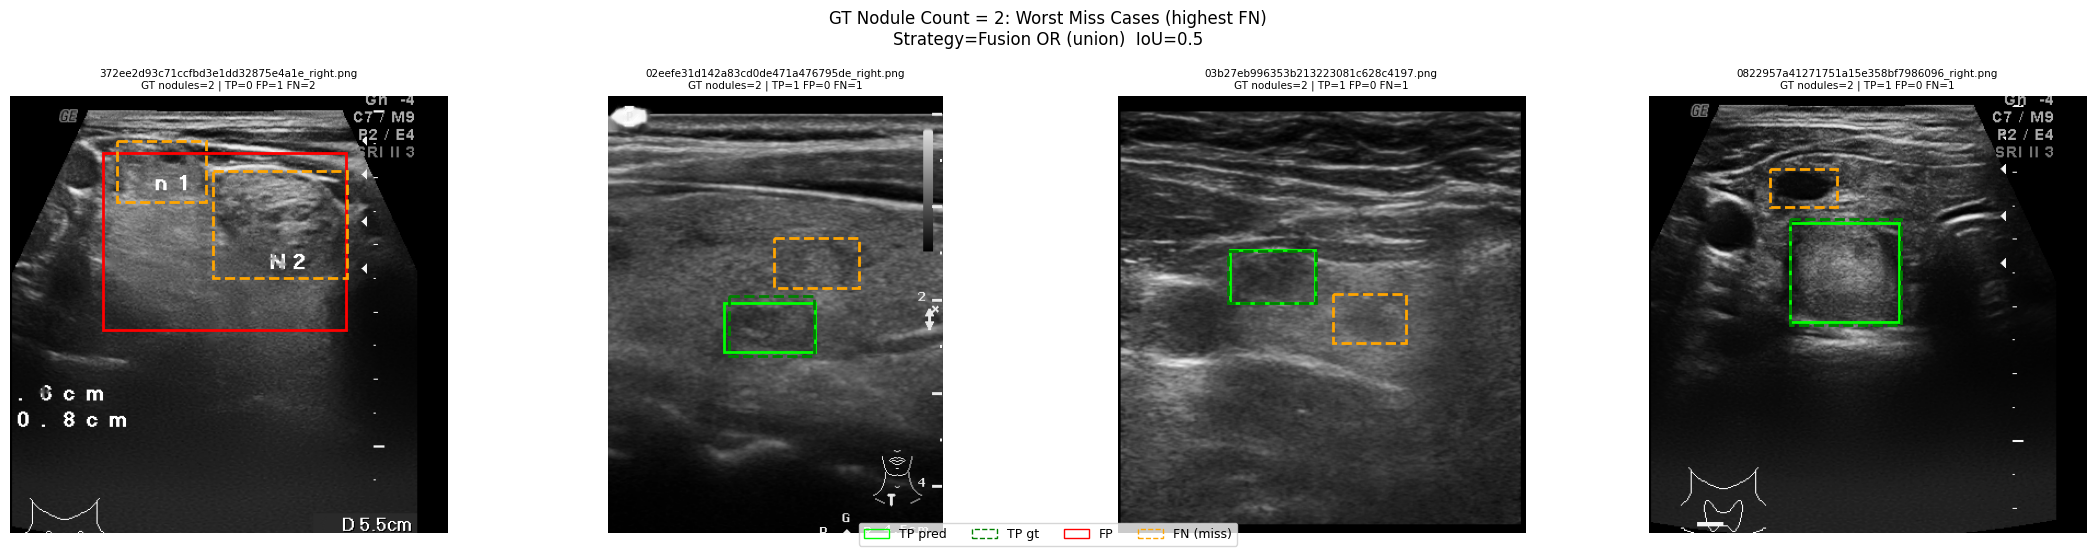

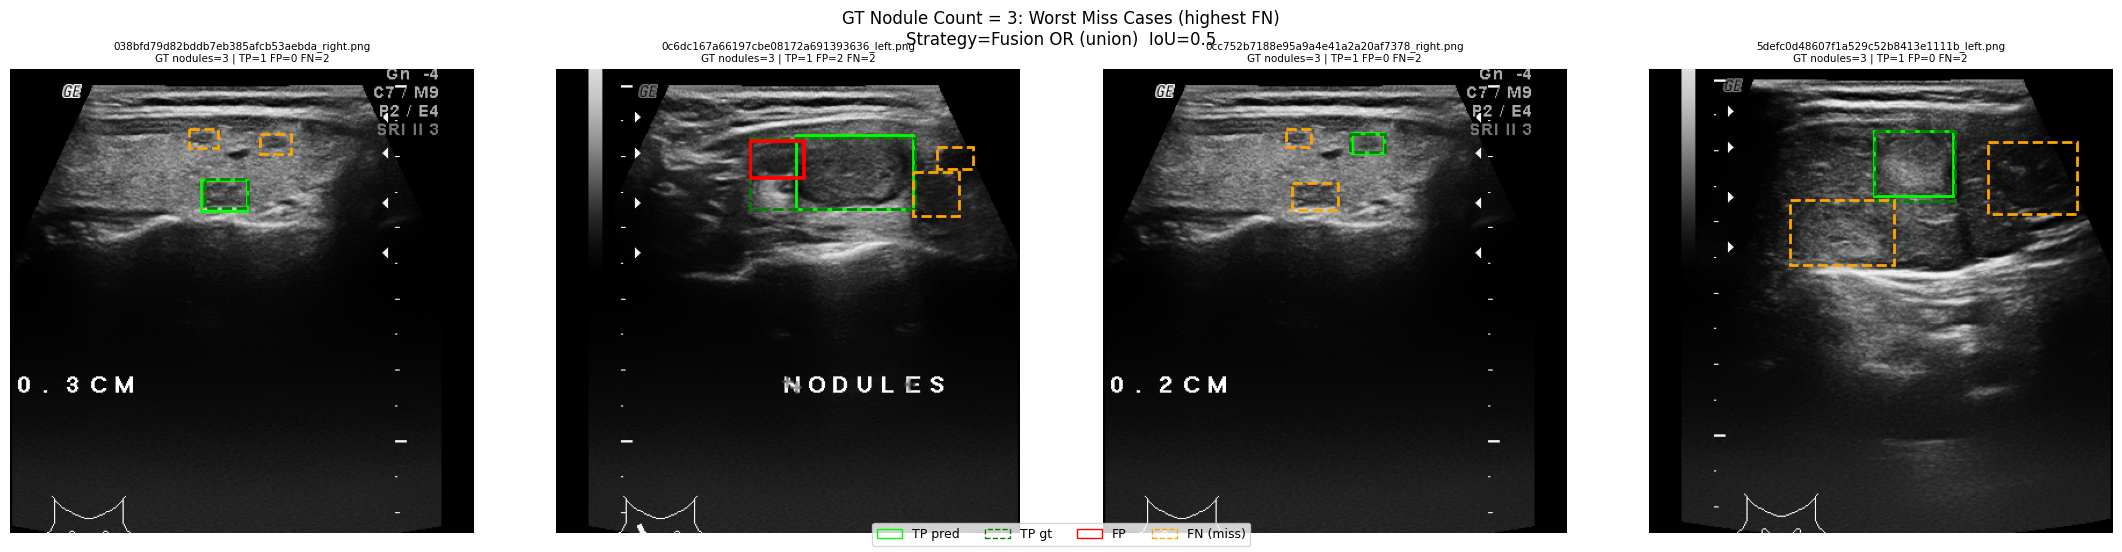

In [105]:
# ============================================================
# Visualization: Poor-performing cases in multi-nodule images (FN misses)
# ============================================================

def visualize_poor_nodule_count_cases(
    od_raw, seg_raw, results_by_strategy_iou,
    strategy='or', iou_threshold=0.5,
    min_nodule_count=2,   # only images with 2+ nodules
    n_per_group=4,        # images per group (highest FN count first)
    seed=42
):
    rng = random.Random(seed)
    df = results_by_strategy_iou[strategy][iou_threshold].copy()
    df['gt_nodule_count'] = df['file_name'].map(gt_count_map)

    multi_df = df[df['gt_nodule_count'] >= min_nodule_count].copy()

    fn_per_image = (
        multi_df[multi_df['match_type'] == 'FN']
        .groupby('file_name').size()
        .rename('fn_count')
    )
    count_per_image = multi_df.groupby('file_name')['gt_nodule_count'].first()

    img_stats = pd.concat([fn_per_image, count_per_image], axis=1).fillna(0)
    img_stats['fn_count'] = img_stats['fn_count'].astype(int)

    bad_imgs = img_stats[img_stats['fn_count'] > 0].sort_values(
        ['gt_nodule_count', 'fn_count'], ascending=[True, False]
    )

    groups = sorted(bad_imgs['gt_nodule_count'].unique())
    fname_to_idx = {}
    for i, (p, _, _) in enumerate(od_raw):
        stem = Path(p).stem
        fname_to_idx[stem] = i
        fname_to_idx[Path(p).name] = i

    for grp_cnt in groups:
        grp_imgs = bad_imgs[bad_imgs['gt_nodule_count'] == grp_cnt]
        samples = grp_imgs.head(n_per_group).index.tolist()
        n = len(samples)
        if n == 0:
            continue

        fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.5))
        if n == 1:
            axes = [axes]

        for col_i, fname in enumerate(samples):
            ax = axes[col_i]
            ax.axis('off')
            idx = fname_to_idx.get(fname) or fname_to_idx.get(fname + '.png')
            if idx is None:
                continue
            od_path = od_raw[idx][0]
            img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)

            recs = df[df['file_name'] == fname].to_dict('records')
            for rec in recs:
                mt = rec['match_type']
                if mt == 'TP':
                    for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                       (rec['gt_box'],   'green', '--')]:
                        if box:
                            ax.add_patch(plt.Rectangle(
                                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                elif mt == 'FP':
                    b = rec['pred_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='red', facecolor='none'))
                elif mt == 'FN':
                    b = rec['gt_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))

            tp = sum(1 for r in recs if r['match_type'] == 'TP')
            fp = sum(1 for r in recs if r['match_type'] == 'FP')
            fn = sum(1 for r in recs if r['match_type'] == 'FN')
            ax.set_title(f"{fname}\nGT nodules={int(grp_cnt)} | TP={tp} FP={fp} FN={fn}", fontsize=7.5)

        legend_elems = [
            mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
            mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
            mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
            mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN (miss)'),
        ]
        fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=9)
        plt.suptitle(
            f'GT Nodule Count = {int(grp_cnt)}: Worst Miss Cases (highest FN)\n'
            f'Strategy={strategy_labels[strategy]}  IoU={iou_threshold}',
            fontsize=12
        )
        plt.tight_layout()
        plt.show()


visualize_poor_nodule_count_cases(
    od_raw, seg_raw, results_by_strategy_iou,
    strategy='or', iou_threshold=NODULE_COUNT_IOU,
    min_nodule_count=2, n_per_group=4
)

Multi-nodule images (GT >= 2): 116
Good cases (FN=0): 61 (52.6%)



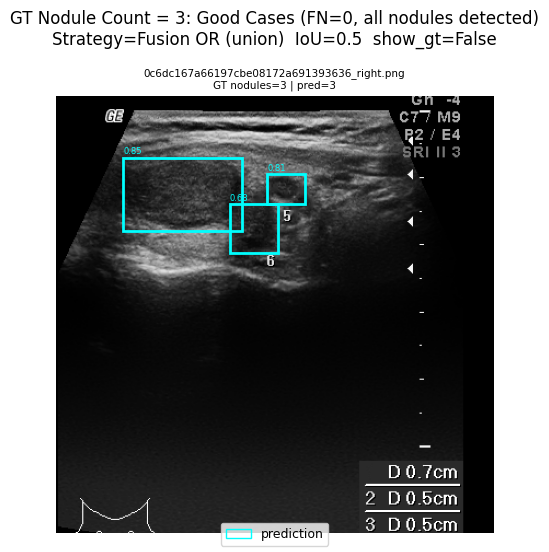

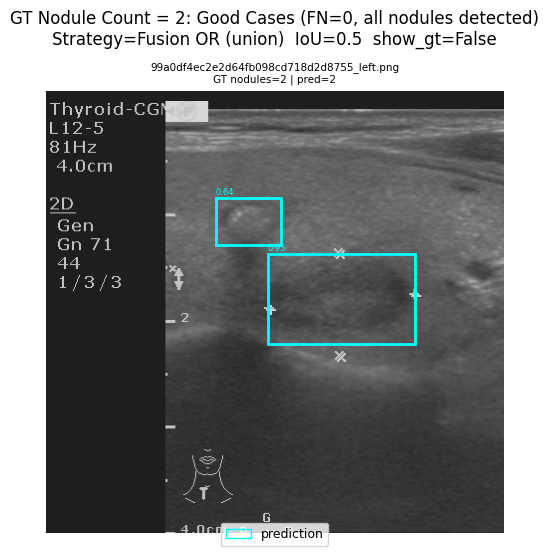

In [106]:

# ============================================================
# Visualization: Good-performing cases in multi-nodule images (all nodules detected)
# ============================================================

def visualize_good_nodule_count_cases(
    od_raw, seg_raw, results_by_strategy_iou,
    strategy='or', iou_threshold=0.5,
    min_nodule_count=2,   # only images with 2+ nodules
    n_per_group=4,        # images per group
    seed=42,
    show_gt=True
):
    """
    顯示 multi-nodule 影像中表現好的例子（FN=0，所有結節都被偵測到）。
    show_gt: True  → 顯示 TP/FP 含 ground truth 框
             False → 只顯示預測框（不含 GT），以信心分數標註
    """
    rng = random.Random(seed)
    df = results_by_strategy_iou[strategy][iou_threshold].copy()
    df['gt_nodule_count'] = df['file_name'].map(gt_count_map)

    multi_df = df[df['gt_nodule_count'] >= min_nodule_count].copy()

    # 計算每張影像的 FN 數量
    fn_per_image = (
        multi_df[multi_df['match_type'] == 'FN']
        .groupby('file_name').size()
        .rename('fn_count')
    )
    tp_per_image = (
        multi_df[multi_df['match_type'] == 'TP']
        .groupby('file_name').size()
        .rename('tp_count')
    )
    count_per_image = multi_df.groupby('file_name')['gt_nodule_count'].first()

    img_stats = pd.concat([fn_per_image, tp_per_image, count_per_image], axis=1).fillna(0)
    img_stats['fn_count'] = img_stats['fn_count'].astype(int)
    img_stats['tp_count'] = img_stats['tp_count'].astype(int)

    # 篩選出 FN=0 的影像（所有 GT 結節都被偵測到）
    good_imgs = img_stats[img_stats['fn_count'] == 0].copy()
    # 按結節數量排序，優先顯示較多結節的好例子
    good_imgs = good_imgs.sort_values('gt_nodule_count', ascending=False)

    print(f"Multi-nodule images (GT >= {min_nodule_count}): {len(img_stats)}")
    print(f"Good cases (FN=0): {len(good_imgs)} ({100*len(good_imgs)/max(len(img_stats),1):.1f}%)")
    print()

    fname_to_idx = {}
    for i, (p, _, _) in enumerate(od_raw):
        stem = Path(p).stem
        fname_to_idx[stem] = i
        fname_to_idx[Path(p).name] = i

    groups = sorted(good_imgs['gt_nodule_count'].unique(), reverse=True)

    for grp_cnt in groups:
        grp_imgs = good_imgs[good_imgs['gt_nodule_count'] == grp_cnt]
        candidates = grp_imgs.index.tolist()
        rng.shuffle(candidates)
        samples = candidates[:n_per_group]
        n = len(samples)
        if n == 0:
            continue

        fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.5))
        if n == 1:
            axes = [axes]

        for col_i, fname in enumerate(samples):
            ax = axes[col_i]
            ax.axis('off')
            idx = fname_to_idx.get(fname) or fname_to_idx.get(fname + '.png')
            if idx is None:
                ax.set_title(f'{fname}\n(image not found)', fontsize=7.5)
                continue
            od_path = od_raw[idx][0]
            img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)

            recs = df[df['file_name'] == fname].to_dict('records')
            for rec in recs:
                mt = rec['match_type']
                if show_gt:
                    # --- 原本模式：顯示 TP/FP 含 GT 框 ---
                    if mt == 'TP':
                        for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                           (rec['gt_box'],   'green', '--')]:
                            if box:
                                ax.add_patch(plt.Rectangle(
                                    (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                    linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                    elif mt == 'FP':
                        b = rec['pred_box']
                        if b:
                            ax.add_patch(plt.Rectangle(
                                (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                linewidth=2, edgecolor='red', facecolor='none'))
                else:
                    # --- 純預測模式：只畫 pred_box，不顯示 GT ---
                    if mt in ('TP', 'FP'):
                        b = rec['pred_box']
                        if b:
                            ax.add_patch(plt.Rectangle(
                                (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                linewidth=2, edgecolor='cyan', facecolor='none'))
                            conf = rec.get('conf')
                            label = f"{conf:.2f}" if conf is not None else ''
                            ax.text(b[0], b[1]-4, label, color='cyan', fontsize=6)

            tp = sum(1 for r in recs if r['match_type'] == 'TP')
            fp = sum(1 for r in recs if r['match_type'] == 'FP')
            fn = sum(1 for r in recs if r['match_type'] == 'FN')
            if show_gt:
                tp_ious = [r['iou'] for r in recs if r['match_type'] == 'TP' and r['iou'] is not None]
                mean_iou = np.mean(tp_ious) if tp_ious else float('nan')
                ax.set_title(f"{fname}\nGT nodules={int(grp_cnt)} | TP={tp} FP={fp} FN={fn} | mean IoU={mean_iou:.2f}", fontsize=7.5)
            else:
                n_pred = sum(1 for r in recs if r['match_type'] in ('TP', 'FP'))
                ax.set_title(f"{fname}\nGT nodules={int(grp_cnt)} | pred={n_pred}", fontsize=7.5)

        if show_gt:
            legend_elems = [
                mpatches.Patch(edgecolor='lime',  facecolor='none', linestyle='-',  label='TP pred'),
                mpatches.Patch(edgecolor='green', facecolor='none', linestyle='--', label='TP gt'),
                mpatches.Patch(edgecolor='red',   facecolor='none', linestyle='-',  label='FP'),
            ]
        else:
            legend_elems = [
                mpatches.Patch(edgecolor='cyan', facecolor='none', linestyle='-', label='prediction'),
            ]
        fig.legend(handles=legend_elems, loc='lower center', ncol=3, fontsize=9)
        plt.suptitle(
            f'GT Nodule Count = {int(grp_cnt)}: Good Cases (FN=0, all nodules detected)\n'
            f'Strategy={strategy_labels[strategy]}  IoU={iou_threshold}  show_gt={show_gt}',
            fontsize=12
        )
        plt.tight_layout()
        plt.show()


# 調整 show_gt: True（含 ground truth）| False（只顯示預測框）
visualize_good_nodule_count_cases(
    od_raw, seg_raw, results_by_strategy_iou,
    strategy='or', iou_threshold=NODULE_COUNT_IOU,
    min_nodule_count=2, n_per_group=1,
    show_gt=False,
    seed = None
)


### Analysis: In Multi-Nodule Images, Is the Largest Nodule Detected?

Multi-nodule images (GT >= 2): 116
Largest nodule detected (TP): 97  (83.6%)
Largest nodule missed   (FN): 19  (16.4%)

=== Largest Nodule Detection Rate by Nodule Count Group ===


,GT nodules,Images,Largest TP,Detection rate (%)
0,2,102,87,85.294118
1,3,14,10,71.428571


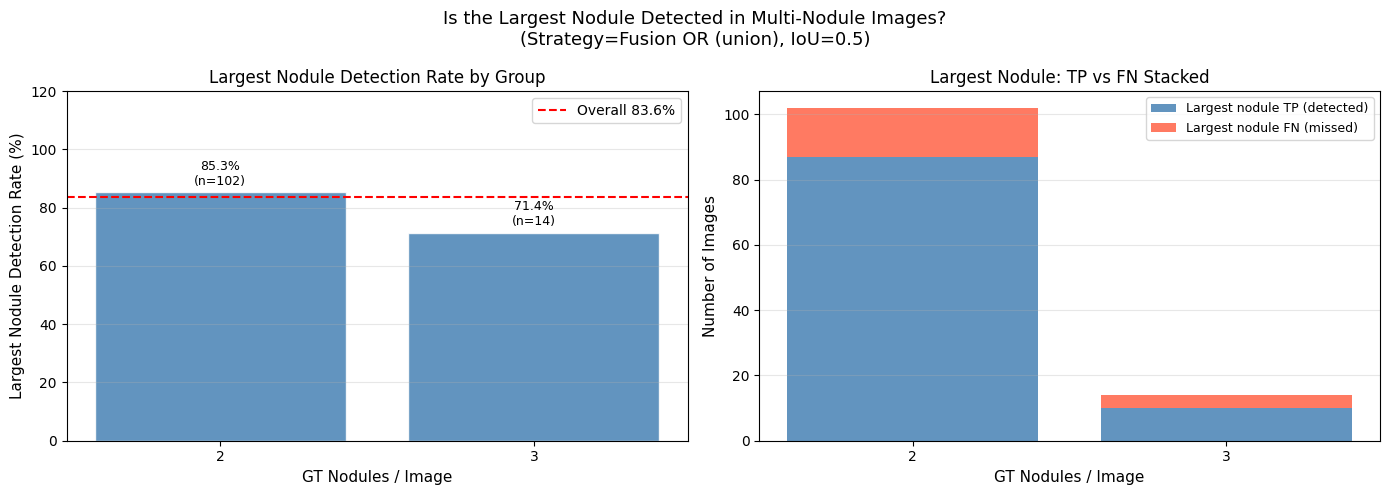

In [107]:
# ============================================================
# Analysis: In multi-nodule images, is the largest nodule (pixel area) detected?
# ============================================================

def box_area(box):
    if box is None:
        return 0.0
    return max(0.0, box[2] - box[0]) * max(0.0, box[3] - box[1])

LARGEST_NODULE_IOU   = NODULE_COUNT_IOU
LARGEST_NODULE_STRAT = 'or'

df_ln = results_by_strategy_iou[LARGEST_NODULE_STRAT][LARGEST_NODULE_IOU].copy()
df_ln['gt_nodule_count'] = df_ln['file_name'].map(gt_count_map)

# Only images with 2+ GT nodules
multi_fnames = df_ln[df_ln['gt_nodule_count'] >= 2]['file_name'].unique()

results_largest = []

for fname in multi_fnames:
    recs = df_ln[df_ln['file_name'] == fname]
    gt_recs = recs[recs['match_type'].isin(['TP', 'FN'])].copy()
    gt_recs = gt_recs.assign(gt_area=gt_recs['gt_box'].apply(box_area))

    if len(gt_recs) == 0:
        continue

    largest_idx = gt_recs['gt_area'].idxmax()
    largest_rec = gt_recs.loc[largest_idx]

    results_largest.append({
        'file_name':        fname,
        'gt_count':         int(largest_rec['gt_nodule_count']),
        'largest_gt_area':  largest_rec['gt_area'],
        'largest_detected': (largest_rec['match_type'] == 'TP'),
        'largest_gt_box':   largest_rec['gt_box'],
        'tp_count':         (recs['match_type'] == 'TP').sum(),
        'fn_count':         (recs['match_type'] == 'FN').sum(),
        'fp_count':         (recs['match_type'] == 'FP').sum(),
    })

largest_df = pd.DataFrame(results_largest)

# ---- Overall stats ----
n_total    = len(largest_df)
n_detected = largest_df['largest_detected'].sum()
pct        = n_detected / n_total * 100

print(f"Multi-nodule images (GT >= 2): {n_total}")
print(f"Largest nodule detected (TP): {int(n_detected)}  ({pct:.1f}%)")
print(f"Largest nodule missed   (FN): {int(n_total - n_detected)}  ({100-pct:.1f}%)")

# ---- Per nodule-count group ----
grp_stat = (
    largest_df
    .groupby('gt_count')
    .agg(
        n_images           = ('file_name', 'count'),
        n_largest_detected = ('largest_detected', 'sum'),
    )
    .reset_index()
)
grp_stat['pct_detected'] = grp_stat['n_largest_detected'] / grp_stat['n_images'] * 100
grp_stat['label'] = grp_stat['gt_count'].apply(
    lambda n: f'>={MAX_NODULE_SHOW}' if n >= MAX_NODULE_SHOW else str(n)
)

print("\n=== Largest Nodule Detection Rate by Nodule Count Group ===")
display(grp_stat[['label', 'n_images', 'n_largest_detected', 'pct_detected']].rename(
    columns={'label': 'GT nodules', 'n_images': 'Images',
             'n_largest_detected': 'Largest TP', 'pct_detected': 'Detection rate (%)'}
))

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: detection rate per group
ax = axes[0]
bars = ax.bar(grp_stat['label'], grp_stat['pct_detected'],
              color='steelblue', alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(bars, grp_stat.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{row['pct_detected']:.1f}%\n(n={int(row['n_images'])})",
            ha='center', va='bottom', fontsize=9)
ax.axhline(pct, color='red', linestyle='--', linewidth=1.5, label=f'Overall {pct:.1f}%')
ax.set_xlabel('GT Nodules / Image', fontsize=11)
ax.set_ylabel('Largest Nodule Detection Rate (%)', fontsize=11)
ax.set_title('Largest Nodule Detection Rate by Group', fontsize=12)
ax.set_ylim(0, 120)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Right: TP vs FN stacked bar
ax2 = axes[1]
n_missed = grp_stat['n_images'] - grp_stat['n_largest_detected']
x = np.arange(len(grp_stat))
ax2.bar(x, grp_stat['n_largest_detected'], label='Largest nodule TP (detected)',
        color='steelblue', alpha=0.85)
ax2.bar(x, n_missed, bottom=grp_stat['n_largest_detected'],
        label='Largest nodule FN (missed)', color='tomato', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(grp_stat['label'], fontsize=10)
ax2.set_xlabel('GT Nodules / Image', fontsize=11)
ax2.set_ylabel('Number of Images', fontsize=11)
ax2.set_title('Largest Nodule: TP vs FN Stacked', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Is the Largest Nodule Detected in Multi-Nodule Images?\n'
    f'(Strategy={strategy_labels[LARGEST_NODULE_STRAT]}, IoU={LARGEST_NODULE_IOU})',
    fontsize=13
)
plt.tight_layout()
plt.show()

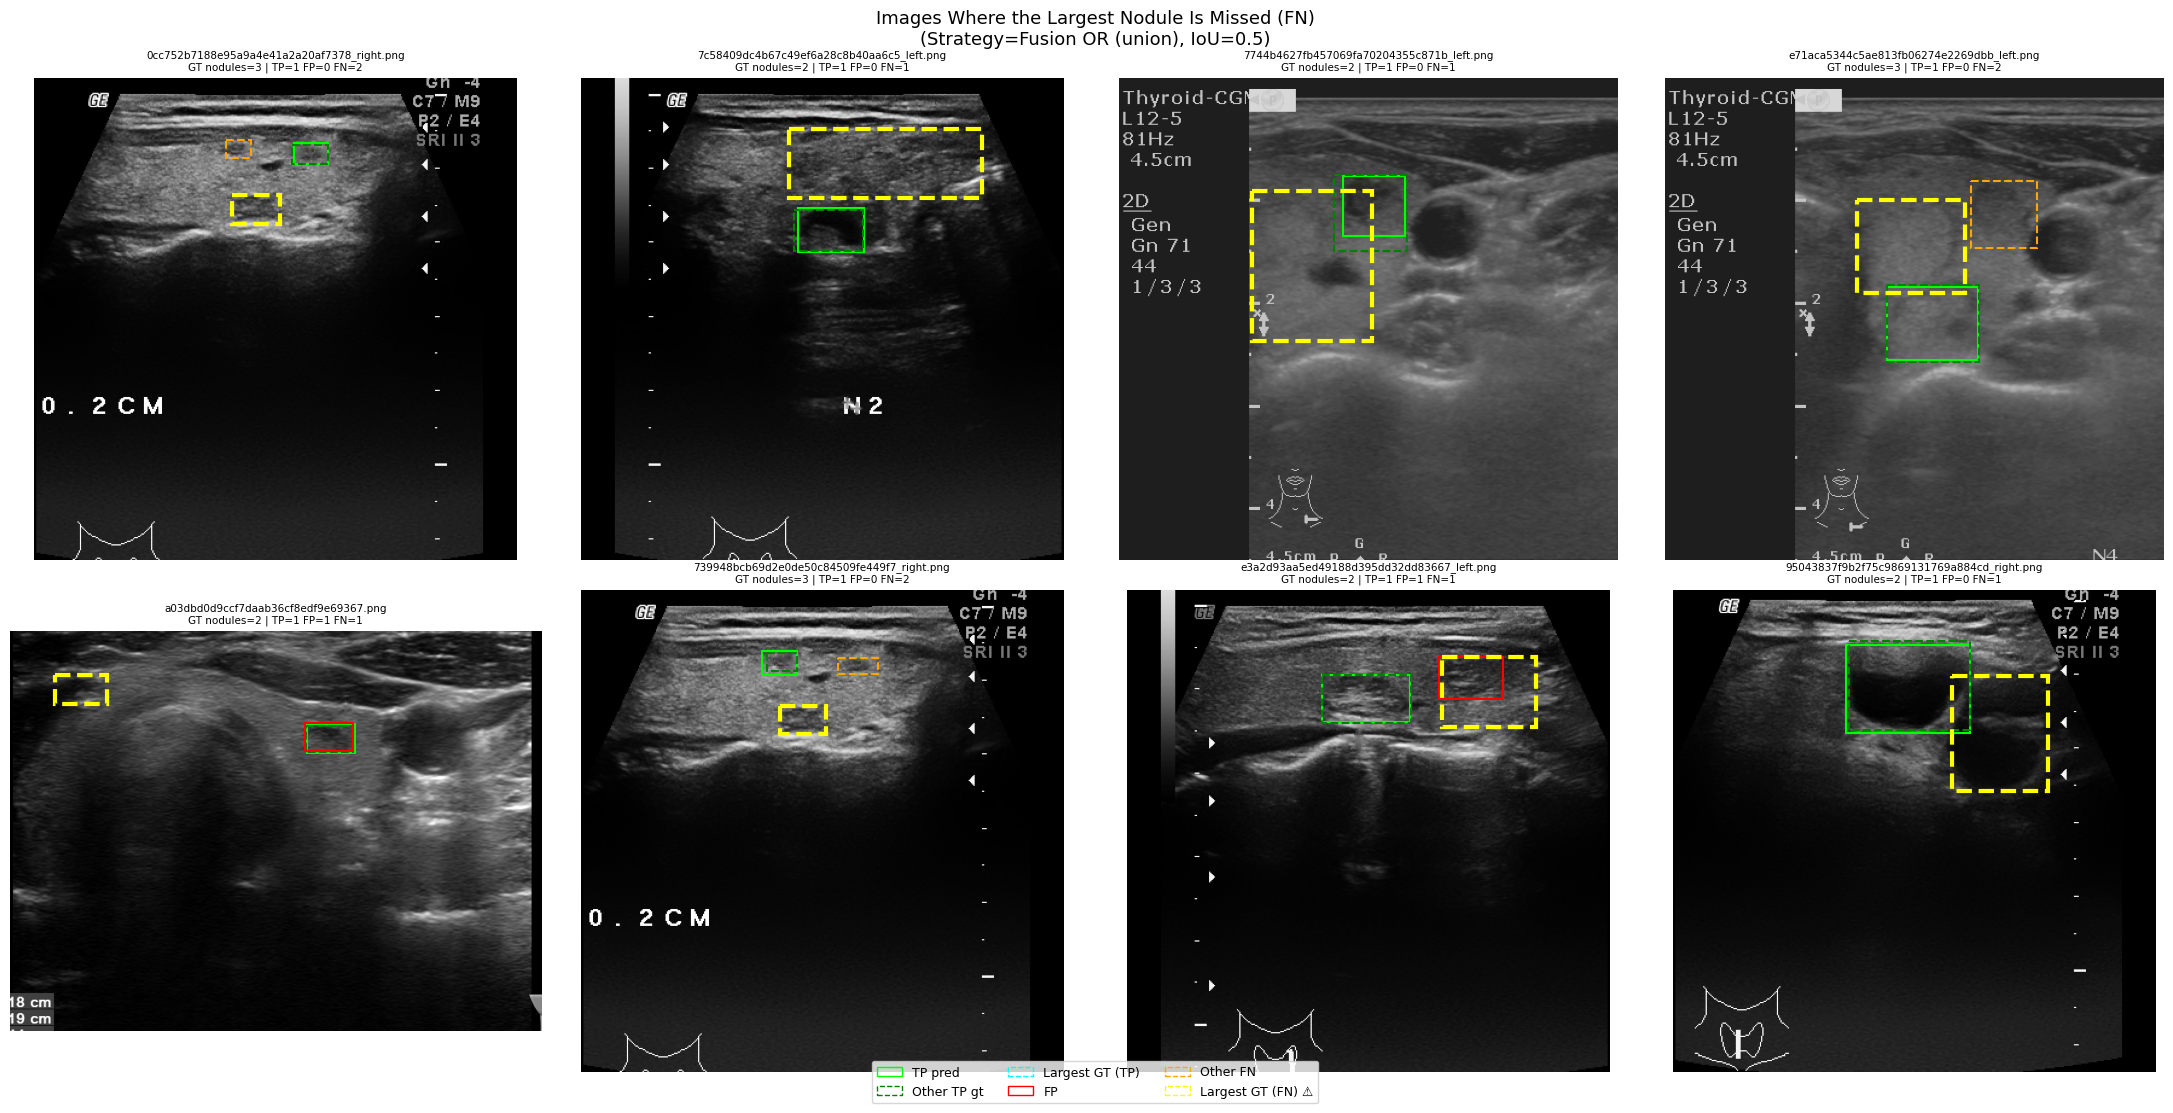

In [108]:
# ============================================================
# Visualization: Images where the largest nodule is missed (FN)
# ============================================================

def visualize_largest_nodule_missed(
    od_raw, df_ln, largest_df,
    n=8, ncols=4, seed=42
):
    """
    Color coding:
    - Yellow dashed:  largest GT nodule, missed (FN)  [key case]
    - Orange dashed:  other FN nodules
    - Cyan dashed:    largest GT nodule, detected (TP)
    - Green dashed:   other TP GT boxes
    - Lime solid:     TP pred boxes
    - Red solid:      FP
    """
    rng = random.Random(seed)
    missed = largest_df[~largest_df['largest_detected']]['file_name'].tolist()
    samples = rng.sample(missed, min(n, len(missed)))

    nrows = (len(samples) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows))
    axes_flat = np.array(axes).flatten()
    for ax in axes_flat:
        ax.axis('off')

    fname_to_idx = {}
    for i, (p, _, _) in enumerate(od_raw):
        fname_to_idx[Path(p).stem] = i
        fname_to_idx[Path(p).name] = i

    for i, fname in enumerate(samples):
        ax = axes_flat[i]
        idx = fname_to_idx.get(fname) or fname_to_idx.get(fname + '.png')
        if idx is None:
            continue
        od_path = od_raw[idx][0]
        img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        row_info = largest_df[largest_df['file_name'] == fname]
        largest_box = row_info['largest_gt_box'].values[0] if len(row_info) else None

        recs = df_ln[df_ln['file_name'] == fname].to_dict('records')
        for rec in recs:
            mt = rec['match_type']
            gb = rec.get('gt_box')
            pb = rec.get('pred_box')

            is_largest_gt = (gb is not None and largest_box is not None and gb == largest_box)

            if mt == 'TP':
                gt_color = 'cyan' if is_largest_gt else 'green'
                gt_lw    = 3      if is_largest_gt else 1.5
                for box, c, ls, lw in [
                    (pb, 'lime',   '-',  1.5),
                    (gb, gt_color, '--', gt_lw),
                ]:
                    if box:
                        ax.add_patch(plt.Rectangle(
                            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                            linewidth=lw, edgecolor=c, facecolor='none', linestyle=ls))
            elif mt == 'FP':
                if pb:
                    ax.add_patch(plt.Rectangle(
                        (pb[0], pb[1]), pb[2]-pb[0], pb[3]-pb[1],
                        linewidth=1.5, edgecolor='red', facecolor='none'))
            elif mt == 'FN':
                ec = 'yellow' if is_largest_gt else 'orange'
                lw = 3        if is_largest_gt else 1.5
                if gb:
                    ax.add_patch(plt.Rectangle(
                        (gb[0], gb[1]), gb[2]-gb[0], gb[3]-gb[1],
                        linewidth=lw, edgecolor=ec, facecolor='none', linestyle='--'))

        tp  = sum(1 for r in recs if r['match_type'] == 'TP')
        fp  = sum(1 for r in recs if r['match_type'] == 'FP')
        fn  = sum(1 for r in recs if r['match_type'] == 'FN')
        cnt = row_info['gt_count'].values[0] if len(row_info) else '?'
        ax.set_title(f"{fname}\nGT nodules={cnt} | TP={tp} FP={fp} FN={fn}", fontsize=7.5)

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='Other TP gt'),
        mpatches.Patch(edgecolor='cyan',   facecolor='none', linestyle='--', label='Largest GT (TP)'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='Other FN'),
        mpatches.Patch(edgecolor='yellow', facecolor='none', linestyle='--', label='Largest GT (FN) ⚠️'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=3, fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(
        f'Images Where the Largest Nodule Is Missed (FN)\n'
        f'(Strategy={strategy_labels[LARGEST_NODULE_STRAT]}, IoU={LARGEST_NODULE_IOU})',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()


visualize_largest_nodule_missed(od_raw, df_ln, largest_df, n=8, ncols=4, seed=42)

### Analysis: In Multi-Nodule Images, Are Detected Nodules Larger or Smaller Than the Per-Image Average?

=== Detected Nodule Size Relative to Per-Image Average ===
TP  relative_size:  mean=1.060  median=1.057  n=182
FN  relative_size:  mean=0.828  median=0.771  n=64

relative_size > 1 → larger than the image's nodule average
relative_size < 1 → smaller than the image's nodule average


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/2949789510.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


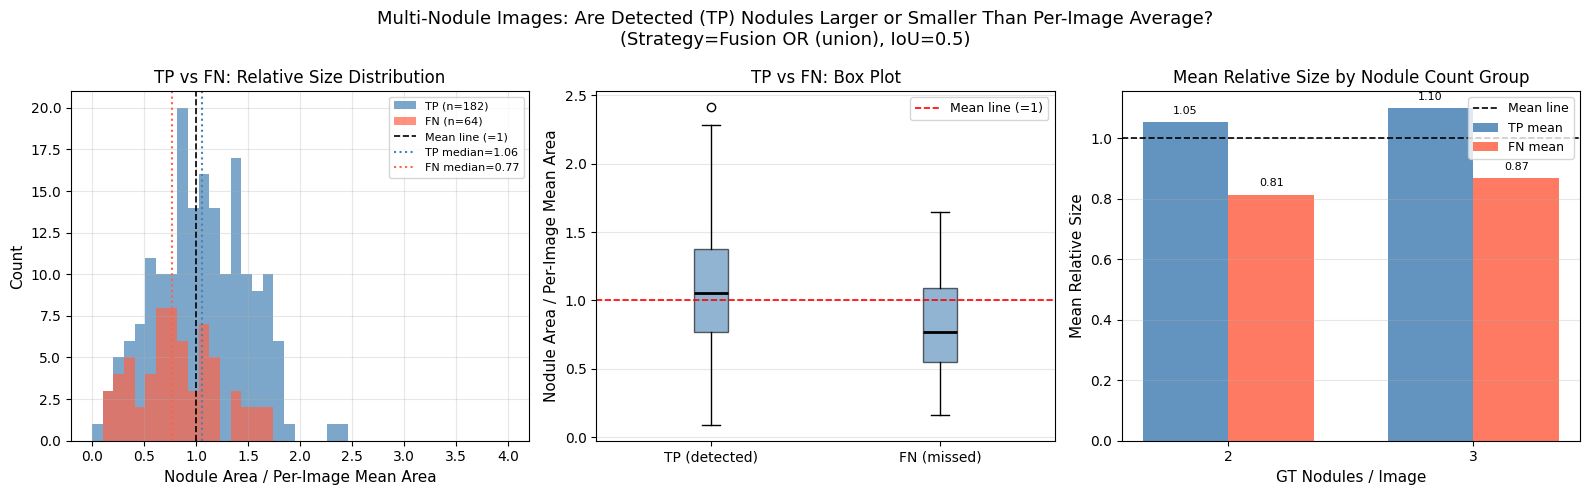

In [109]:
# ============================================================
# Analysis: In multi-nodule images, are TP / FN nodules larger or smaller
#           than the per-image average nodule size?
# ============================================================
# relative_size = nodule area / mean area of all GT nodules in that image
#   > 1 → larger than the image average
#   < 1 → smaller than the image average
# ============================================================

REL_SIZE_IOU   = NODULE_COUNT_IOU
REL_SIZE_STRAT = 'or'

df_rel = results_by_strategy_iou[REL_SIZE_STRAT][REL_SIZE_IOU].copy()
df_rel['gt_nodule_count'] = df_rel['file_name'].map(gt_count_map)

# Only multi-nodule images
df_rel = df_rel[df_rel['gt_nodule_count'] >= 2].copy()

# Compute GT nodule area (TP + FN only)
gt_mask = df_rel['match_type'].isin(['TP', 'FN'])
df_rel.loc[gt_mask, 'gt_area'] = df_rel.loc[gt_mask, 'gt_box'].apply(box_area)

# Per-image mean GT area
img_mean_area = (
    df_rel[gt_mask]
    .groupby('file_name')['gt_area']
    .mean()
    .rename('img_mean_area')
)
df_rel = df_rel.join(img_mean_area, on='file_name')

# Relative size
df_rel.loc[gt_mask, 'relative_size'] = (
    df_rel.loc[gt_mask, 'gt_area'] / df_rel.loc[gt_mask, 'img_mean_area']
)

tp_rel = df_rel.loc[df_rel['match_type'] == 'TP', 'relative_size'].dropna()
fn_rel = df_rel.loc[df_rel['match_type'] == 'FN', 'relative_size'].dropna()

print("=== Detected Nodule Size Relative to Per-Image Average ===")
print(f"TP  relative_size:  mean={tp_rel.mean():.3f}  median={tp_rel.median():.3f}  n={len(tp_rel)}")
print(f"FN  relative_size:  mean={fn_rel.mean():.3f}  median={fn_rel.median():.3f}  n={len(fn_rel)}")
print()
print("relative_size > 1 → larger than the image's nodule average")
print("relative_size < 1 → smaller than the image's nodule average")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, 4, 40)
ax.hist(tp_rel.clip(upper=4), bins=bins, alpha=0.7, color='steelblue', label=f'TP (n={len(tp_rel)})')
ax.hist(fn_rel.clip(upper=4), bins=bins, alpha=0.7, color='tomato',    label=f'FN (n={len(fn_rel)})')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Mean line (=1)')
ax.axvline(tp_rel.median(), color='steelblue', linestyle=':', linewidth=1.5,
           label=f'TP median={tp_rel.median():.2f}')
ax.axvline(fn_rel.median(), color='tomato',    linestyle=':', linewidth=1.5,
           label=f'FN median={fn_rel.median():.2f}')
ax.set_xlabel('Nodule Area / Per-Image Mean Area', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('TP vs FN: Relative Size Distribution', fontsize=12)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Center: box plot
ax2 = axes[1]
ax2.boxplot(
    [tp_rel.clip(upper=5).values, fn_rel.clip(upper=5).values],
    labels=['TP (detected)', 'FN (missed)'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
)
ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Mean line (=1)')
ax2.set_ylabel('Nodule Area / Per-Image Mean Area', fontsize=11)
ax2.set_title('TP vs FN: Box Plot', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Right: mean relative size per nodule-count group
ax3 = axes[2]
cnt_groups = sorted(df_rel[gt_mask]['gt_nodule_count'].unique())
tp_means, fn_means, x_labels = [], [], []
for cnt in cnt_groups:
    lbl = f'>={MAX_NODULE_SHOW}' if cnt >= MAX_NODULE_SHOW else str(int(cnt))
    sub = df_rel[gt_mask & (df_rel['gt_nodule_count'] == cnt)]
    tp_m = sub.loc[sub['match_type'] == 'TP', 'relative_size'].mean()
    fn_m = sub.loc[sub['match_type'] == 'FN', 'relative_size'].mean()
    tp_means.append(tp_m)
    fn_means.append(fn_m)
    x_labels.append(lbl)

x = np.arange(len(x_labels))
w = 0.35
ax3.bar(x - w/2, tp_means, w, label='TP mean', color='steelblue', alpha=0.85)
ax3.bar(x + w/2, fn_means, w, label='FN mean', color='tomato',    alpha=0.85)
ax3.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Mean line')
for xi, (tm, fm) in enumerate(zip(tp_means, fn_means)):
    if not np.isnan(tm):
        ax3.text(xi - w/2, tm + 0.02, f'{tm:.2f}', ha='center', va='bottom', fontsize=8)
    if not np.isnan(fm):
        ax3.text(xi + w/2, fm + 0.02, f'{fm:.2f}', ha='center', va='bottom', fontsize=8)
ax3.set_xticks(x)
ax3.set_xticklabels(x_labels, fontsize=10)
ax3.set_xlabel('GT Nodules / Image', fontsize=11)
ax3.set_ylabel('Mean Relative Size', fontsize=11)
ax3.set_title('Mean Relative Size by Nodule Count Group', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Multi-Nodule Images: Are Detected (TP) Nodules Larger or Smaller Than Per-Image Average?\n'
    f'(Strategy={strategy_labels[REL_SIZE_STRAT]}, IoU={REL_SIZE_IOU})',
    fontsize=13
)
plt.tight_layout()
plt.show()

### Analysis: Within Multi-Nodule Images, Does a Larger Size Gap Between Nodules Correlate with Higher Model Confidence?

Total within-image pairs: 71
Pairs where larger nodule has higher conf (conf_diff > 0): 39 (54.9%)
Mean conf_diff: 0.0196

Correlation (area_diff  vs conf_diff): r=0.207  p=8.397e-02
Correlation (area_ratio vs conf_diff): r=0.272  p=2.177e-02

=== Mean confidence by within-image size rank (1 = largest) ===


,size_rank,mean,std,median,count
0,1,0.846487,0.092688,0.883836,115
1,2,0.792639,0.120548,0.833075,63


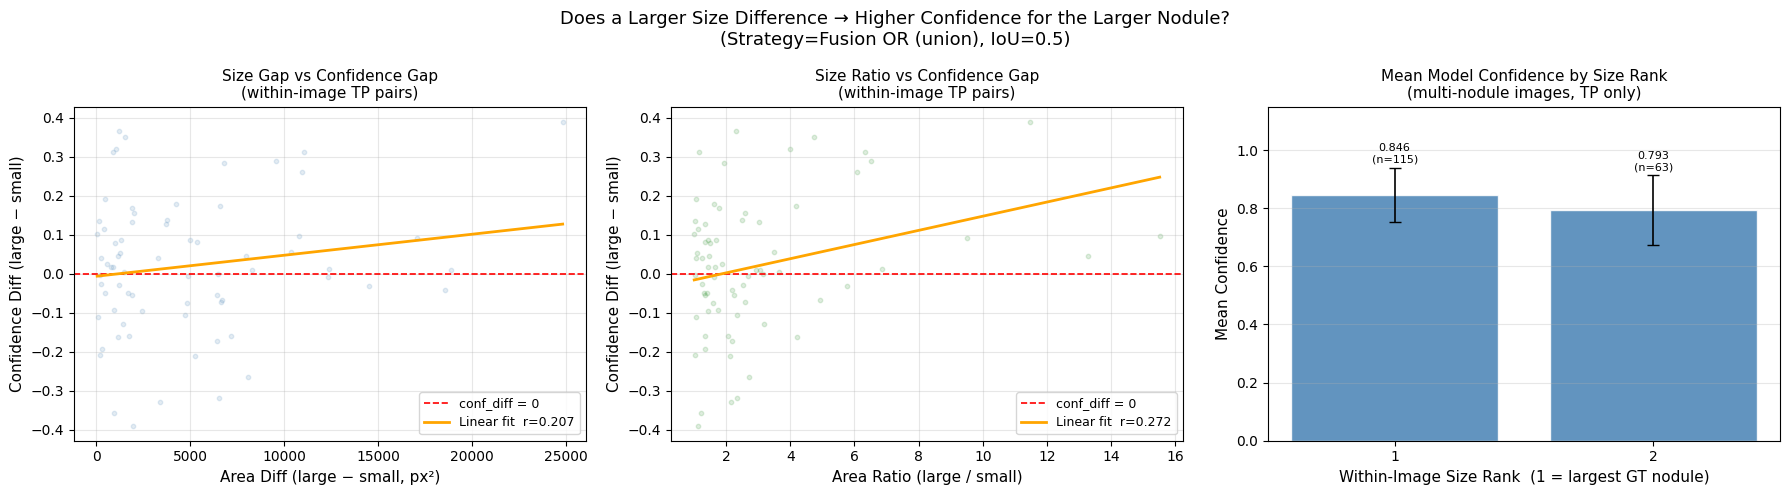

In [110]:
# ============================================================
# Analysis: In images with 2+ TP detections, for every pair of nodules
# (large, small) within the same image:
#   area_diff  = area(large) - area(small)
#   area_ratio = area(large) / area(small)
#   conf_large, conf_small, conf_diff = conf(large) - conf(small)
# Question: does a bigger size gap → higher confidence for the larger one?
# ============================================================

CONF_DIFF_IOU   = NODULE_COUNT_IOU
CONF_DIFF_STRAT = 'or'

df_cd = results_by_strategy_iou[CONF_DIFF_STRAT][CONF_DIFF_IOU].copy()
df_cd['gt_nodule_count'] = df_cd['file_name'].map(gt_count_map)

# Only TP in multi-nodule images
tp_multi = df_cd[
    (df_cd['match_type'] == 'TP') &
    (df_cd['gt_nodule_count'] >= 2)
].copy()
tp_multi['gt_area'] = tp_multi['gt_box'].apply(box_area)

# ── Pairwise comparison within each image ──────────────────
pair_records = []

for fname, grp in tp_multi.groupby('file_name'):
    nodules = grp[['gt_area', 'conf']].dropna().values  # [[area, conf], ...]
    if len(nodules) < 2:
        continue
    # All ordered pairs (i, j) where area[i] >= area[j]
    for i in range(len(nodules)):
        for j in range(len(nodules)):
            if i == j:
                continue
            a_i, c_i = nodules[i]
            a_j, c_j = nodules[j]
            if a_i >= a_j:
                pair_records.append({
                    'file_name':  fname,
                    'area_large': a_i,
                    'area_small': a_j,
                    'conf_large': c_i,
                    'conf_small': c_j,
                    'area_diff':  a_i - a_j,
                    'area_ratio': a_i / a_j if a_j > 0 else np.nan,
                    'conf_diff':  c_i - c_j,   # positive → larger nodule has higher conf
                })

pair_df = pd.DataFrame(pair_records).dropna()

print(f"Total within-image pairs: {len(pair_df)}")
print(f"Pairs where larger nodule has higher conf (conf_diff > 0): "
      f"{(pair_df['conf_diff'] > 0).sum()} ({(pair_df['conf_diff'] > 0).mean()*100:.1f}%)")
print(f"Mean conf_diff: {pair_df['conf_diff'].mean():.4f}")

# Pearson correlation
from scipy import stats
r_diff,  p_diff  = stats.pearsonr(pair_df['area_diff'],  pair_df['conf_diff'])
r_ratio, p_ratio = stats.pearsonr(pair_df['area_ratio'].clip(upper=20), pair_df['conf_diff'])
print(f"\nCorrelation (area_diff  vs conf_diff): r={r_diff:.3f}  p={p_diff:.3e}")
print(f"Correlation (area_ratio vs conf_diff): r={r_ratio:.3f}  p={p_ratio:.3e}")

# ── Per-nodule rank vs confidence ──────────────────────────
# Within each image, rank nodules by GT area (1 = largest)
tp_multi_sorted = tp_multi.copy()
tp_multi_sorted['size_rank'] = (
    tp_multi_sorted.groupby('file_name')['gt_area']
    .rank(ascending=False, method='min')
    .astype(int)
)

rank_conf = (
    tp_multi_sorted.groupby('size_rank')['conf']
    .agg(['mean', 'std', 'median', 'count'])
    .reset_index()
)
rank_conf['std'] = rank_conf['std'].fillna(0)
rank_conf = rank_conf[rank_conf['count'] >= 5]   # only ranks with enough samples
print("\n=== Mean confidence by within-image size rank (1 = largest) ===")
display(rank_conf)

# ── Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: scatter area_diff vs conf_diff
ax = axes[0]
clip_diff = pair_df['area_diff'].clip(upper=pair_df['area_diff'].quantile(0.99))
ax.scatter(clip_diff, pair_df['conf_diff'],
           alpha=0.15, s=10, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.2, label='conf_diff = 0')
m, b, *_ = stats.linregress(clip_diff, pair_df['conf_diff'])
xs = np.linspace(clip_diff.min(), clip_diff.max(), 200)
ax.plot(xs, m * xs + b, color='orange', linewidth=2,
        label=f'Linear fit  r={r_diff:.3f}')
ax.set_xlabel('Area Diff (large − small, px²)', fontsize=11)
ax.set_ylabel('Confidence Diff (large − small)', fontsize=11)
ax.set_title('Size Gap vs Confidence Gap\n(within-image TP pairs)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Center: scatter area_ratio vs conf_diff
ax2 = axes[1]
clip_ratio = pair_df['area_ratio'].clip(upper=pair_df['area_ratio'].quantile(0.99))
ax2.scatter(clip_ratio, pair_df['conf_diff'],
            alpha=0.15, s=10, color='forestgreen')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.2, label='conf_diff = 0')
m2, b2, *_ = stats.linregress(clip_ratio, pair_df['conf_diff'])
xs2 = np.linspace(clip_ratio.min(), clip_ratio.max(), 200)
ax2.plot(xs2, m2 * xs2 + b2, color='orange', linewidth=2,
         label=f'Linear fit  r={r_ratio:.3f}')
ax2.set_xlabel('Area Ratio (large / small)', fontsize=11)
ax2.set_ylabel('Confidence Diff (large − small)', fontsize=11)
ax2.set_title('Size Ratio vs Confidence Gap\n(within-image TP pairs)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Right: mean confidence by size rank (error bar = std)
ax3 = axes[2]
ax3.bar(rank_conf['size_rank'].astype(str), rank_conf['mean'],
        color='steelblue', alpha=0.85, edgecolor='white')
ax3.errorbar(
    x=rank_conf['size_rank'].astype(str),
    y=rank_conf['mean'],
    yerr=rank_conf['std'],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
for _, row in rank_conf.iterrows():
    ax3.text(str(int(row['size_rank'])), row['mean'] + row['std'] + 0.01,
             f"{row['mean']:.3f}\n(n={int(row['count'])})",
             ha='center', va='bottom', fontsize=8)
ax3.set_xlabel('Within-Image Size Rank  (1 = largest GT nodule)', fontsize=11)
ax3.set_ylabel('Mean Confidence', fontsize=11)
ax3.set_title('Mean Model Confidence by Size Rank\n(multi-nodule images, TP only)', fontsize=11)
ax3.set_ylim(0, 1.15)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Does a Larger Size Difference → Higher Confidence for the Larger Nodule?\n'
    f'(Strategy={strategy_labels[CONF_DIFF_STRAT]}, IoU={CONF_DIFF_IOU})',
    fontsize=13
)
plt.tight_layout()
plt.show()

## 性別對效能之影響（Male vs. Female）

從 CG 報告檔案取得病人性別，分析各策略在男女病人上的 Recall、Precision、F1 表現。

In [111]:
# ============================================================
# 建立 patient_ID → SEX 對應表（合併所有 CG 報告檔）
# ============================================================
import glob

GENDER_ANALYSIS_IOU = 0.5

report_files = glob.glob(
    '/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_reports/*.xlsx'
) + [
    '/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data/report_deid.xlsx',
    '/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data_for_future/report_deid.xlsx',
]

sex_parts = []
for f in report_files:
    df_rep = pd.read_excel(f)
    if 'SEX' in df_rep.columns and 'IDCODE' in df_rep.columns:
        sex_parts.append(df_rep[['IDCODE', 'SEX']].dropna())

sex_map = (
    pd.concat(sex_parts)
    .drop_duplicates('IDCODE')
    .set_index('IDCODE')['SEX']
)

# 分佈確認
print("全體病人性別分佈（報告檔合併後）：")
print(sex_map.value_counts().to_string())

# 驗證 val_df 的 match rate
ref_df_sex = results_by_strategy_iou['or'][GENDER_ANALYSIS_IOU]
all_pids   = ref_df_sex['patient_ID'].unique()
matched_pids = [p for p in all_pids if p in sex_map.index]
print(f"\nVal set patients matched: {len(matched_pids)} / {len(all_pids)}")

全體病人性別分佈（報告檔合併後）：
SEX
F    3983
M    1158

Val set patients matched: 616 / 617


In [112]:
# ============================================================
# 各策略 × 性別 → TP/FP/FN 計數 & 指標
# ============================================================

GENDERS = ['F', 'M']
gender_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][GENDER_ANALYSIS_IOU].copy()
    df['gender'] = df['patient_ID'].map(sex_map)

    for gender in GENDERS:
        grp = df[df['gender'] == gender]
        tp = (grp['match_type'] == 'TP').sum()
        fp = (grp['match_type'] == 'FP').sum()
        fn = (grp['match_type'] == 'FN').sum()
        n_images   = grp['file_name'].nunique()
        n_patients = grp['patient_ID'].nunique()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = grp.loc[grp['match_type'] == 'TP', 'iou'].dropna()
        tp_cd  = grp.loc[grp['match_type'] == 'TP', 'center_distance'].dropna()
        gender_records.append({
            'strategy':    strategy,
            'label':       strategy_labels[strategy],
            'gender':      gender,
            'n_images':    n_images,
            'n_patients':  n_patients,
            'TP': tp, 'FP': fp, 'FN': fn,
            'recall':      recall,
            'precision':   precision,
            'f1':          f1,
            'mean_iou':    tp_iou.mean() if len(tp_iou) else np.nan,
            'mean_cd':     tp_cd.mean()  if len(tp_cd)  else np.nan,
        })

gender_df = pd.DataFrame(gender_records)

# 樞紐表
for metric in ['recall', 'precision', 'f1']:
    pivot = gender_df.pivot_table(index='label', columns='gender',
                                   values=metric, aggfunc='first')[GENDERS]
    print(f"=== {metric.capitalize()} by Gender (IoU={GENDER_ANALYSIS_IOU}) ===")
    display(pivot.round(4))
    print()

# 影像 / 病人數
info = gender_df[gender_df['strategy'] == 'or'][['gender', 'n_images', 'n_patients']]
print("影像 / 病人數：")
display(info.set_index('gender').T)

=== Recall by Gender (IoU=0.5) ===


gender,F,M
label,,
Fusion AND (intersection),0.7218,0.6889
Fusion OR (union),0.9301,0.9481
OD only,0.9055,0.9037
Seg only (bbox),0.8870,0.8889



=== Precision by Gender (IoU=0.5) ===


gender,F,M
label,,
Fusion AND (intersection),0.9781,0.9789
Fusion OR (union),0.8045,0.7642
OD only,0.9283,0.9004
Seg only (bbox),0.9585,0.9375



=== F1 by Gender (IoU=0.5) ===


gender,F,M
label,,
Fusion AND (intersection),0.8306,0.8087
Fusion OR (union),0.8627,0.8463
OD only,0.9167,0.9020
Seg only (bbox),0.9214,0.9125



影像 / 病人數：


gender,F,M
n_images,1894,468
n_patients,491,125


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:38: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:38: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:38: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:38: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:38: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5

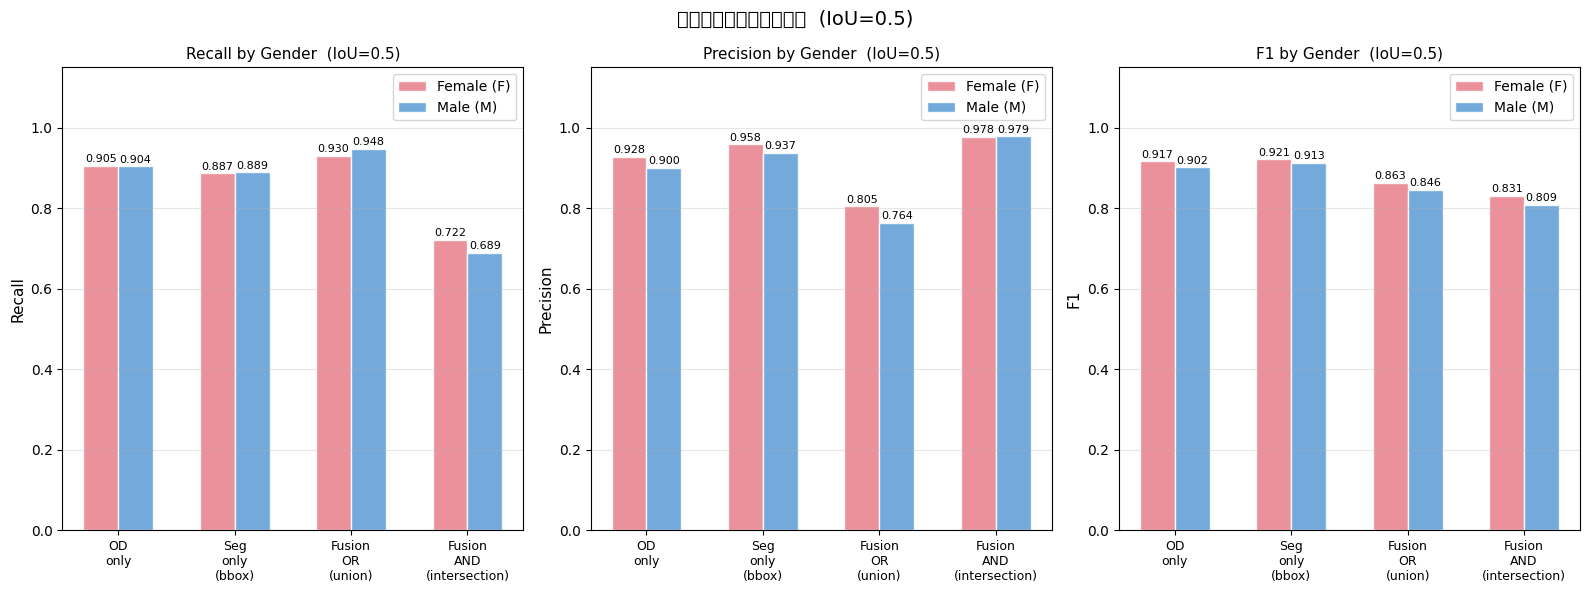

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:66: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:66: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:66: UserWarning: Glyph 36264 (\N{CJK UNIFIED IDEOGRAPH-8DA8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:66: UserWarning: Glyph 21218 (\N{CJK UNIFIED IDEOGRAPH-52E2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/212323894.py:66: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5

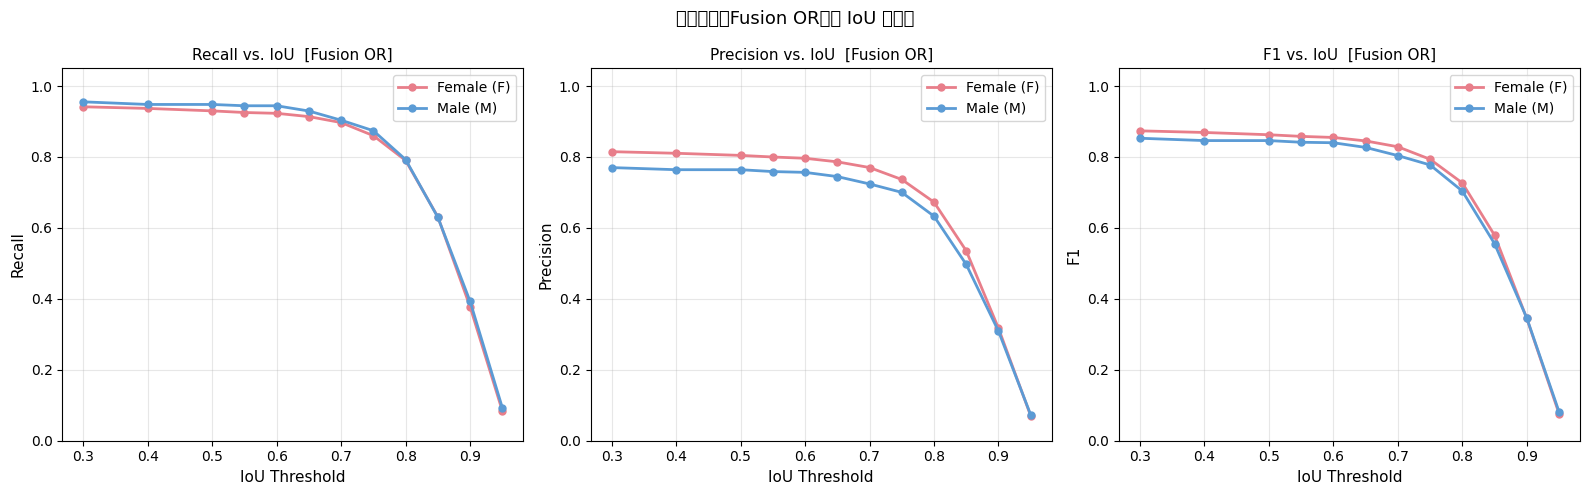

In [113]:
# ============================================================
# 視覺化：性別 × 策略 → Recall / Precision / F1
# ============================================================

metrics_g    = ['recall', 'precision', 'f1']
metric_titles_g = ['Recall', 'Precision', 'F1']
gender_colors = {'F': '#E87E8A', 'M': '#5B9BD5'}

x_g    = np.arange(len(strategies))
w_g    = 0.3
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric, title in zip(axes, metrics_g, metric_titles_g):
    for gi, gender in enumerate(GENDERS):
        vals = []
        for strategy in strategies:
            row = gender_df[(gender_df['strategy'] == strategy) &
                            (gender_df['gender'] == gender)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else np.nan)
        offset = (gi - 0.5) * w_g
        bars = ax.bar(x_g + offset, vals, w_g,
                      label=f"{'Female' if gender=='F' else 'Male'} ({gender})",
                      color=gender_colors[gender], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x_g)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n') for s in strategies], fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Gender  (IoU={GENDER_ANALYSIS_IOU})', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'性別對各策略效能之影響  (IoU={GENDER_ANALYSIS_IOU})', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 跨 IoU 閾值趨勢（以 OR 策略為例）----
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(axes2, metrics_g, metric_titles_g):
    for gender in GENDERS:
        vals = []
        for iou_thr in all_iou_thresholds:
            df_iou = results_by_strategy_iou['or'][iou_thr].copy()
            df_iou['gender'] = df_iou['patient_ID'].map(sex_map)
            grp = df_iou[df_iou['gender'] == gender]
            tp = (grp['match_type'] == 'TP').sum()
            fp = (grp['match_type'] == 'FP').sum()
            fn = (grp['match_type'] == 'FN').sum()
            r, p, f = compute_metrics_from_counts(tp, fp, fn)
            vals.append({'recall': r, 'precision': p, 'f1': f}[metric])
        ax.plot(all_iou_thresholds, vals, marker='o', markersize=5,
                color=gender_colors[gender], linewidth=2,
                label=f"{'Female' if gender=='F' else 'Male'} ({gender})")
    ax.set_xlabel('IoU Threshold', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs. IoU  [Fusion OR]', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('性別趨勢（Fusion OR，跨 IoU 閾值）', fontsize=13)
plt.tight_layout()
plt.show()

## View 對效能之影響（Sagittal vs. Transverse）

從 `data_info_complete.csv` 取得每張影像的拍攝切面（sagittal / transverse），分析各策略在不同 view 的 Recall、Precision、F1 表現。

In [114]:
# ============================================================
# 建立 file_name → view 對應表
# ============================================================

VIEW_ANALYSIS_IOU = 0.5

view_info = pd.read_csv(
    f'{data_root}/yolo_data/all_csv_files/data_info_complete.csv',
    usecols=['file_name', 'view']
).dropna(subset=['view'])

# 統一大小寫，修正 'saggital' 拼法
view_info['view'] = (
    view_info['view'].str.strip().str.lower()
    .replace({'saggital': 'sagittal'})
)

# results_by_strategy_iou 的 file_name 含 .png，csv 不含 → 兩種 key 都建
view_info_png = view_info.copy()
view_info_png['file_name'] = view_info_png['file_name'] + '.png'
view_info_all = pd.concat([view_info, view_info_png], ignore_index=True)

view_map = view_info_all.drop_duplicates('file_name').set_index('file_name')['view']

# 分佈確認
print('View 分佈（data_info_complete.csv）：')
print(view_info['view'].value_counts().to_string())

# 驗證 val set match rate
ref_df_view = results_by_strategy_iou['or'][VIEW_ANALYSIS_IOU]
all_fnames  = ref_df_view['file_name'].unique()
matched_fnames = [f for f in all_fnames if f in view_map.index]
print(f'\nVal set images matched: {len(matched_fnames)} / {len(all_fnames)}')

VIEWS = ['sagittal', 'transverse']


View 分佈（data_info_complete.csv）：
view
sagittal      3691
transverse    3651
left             1

Val set images matched: 1444 / 2364


In [58]:
# ============================================================
# 各策略 × View → TP/FP/FN 計數 & 指標
# ============================================================

view_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][VIEW_ANALYSIS_IOU].copy()
    df['view'] = df['file_name'].map(view_map)

    for view in VIEWS:
        grp = df[df['view'] == view]
        tp = (grp['match_type'] == 'TP').sum()
        fp = (grp['match_type'] == 'FP').sum()
        fn = (grp['match_type'] == 'FN').sum()
        n_images   = grp['file_name'].nunique()
        n_patients = grp['patient_ID'].nunique()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = grp.loc[grp['match_type'] == 'TP', 'iou'].dropna()
        tp_cd  = grp.loc[grp['match_type'] == 'TP', 'center_distance'].dropna()
        view_records.append({
            'strategy':   strategy,
            'label':      strategy_labels[strategy],
            'view':       view,
            'n_images':   n_images,
            'n_patients': n_patients,
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn),
            'recall':     recall,
            'precision':  precision,
            'f1':         f1,
            'mean_iou':   tp_iou.mean() if len(tp_iou) else np.nan,
            'mean_cd':    tp_cd.mean()  if len(tp_cd)  else np.nan,
        })

view_df = pd.DataFrame(view_records)

# 樞紐表
for metric in ['recall', 'precision', 'f1']:
    pivot = view_df.pivot_table(index='label', columns='view',
                                values=metric, aggfunc='first')[VIEWS]
    print(f'=== {metric.capitalize()} by View (IoU={VIEW_ANALYSIS_IOU}) ===')
    display(pivot.round(4))
    print()

# 影像 / 病人數
info = view_df[view_df['strategy'] == 'or'][['view', 'n_images', 'n_patients', 'TP', 'FP', 'FN']]
print('影像 / 病人數：')
display(info.set_index('view').T)


=== Recall by View (IoU=0.5) ===


view,sagittal,transverse
label,,
Fusion AND (intersection),0.9053,0.9418
Fusion OR (union),0.9592,0.9770
OD only,0.9460,0.9594
Seg only (bbox),0.9185,0.9581



=== Precision by View (IoU=0.5) ===


view,sagittal,transverse
label,,
Fusion AND (intersection),0.9344,0.9482
Fusion OR (union),0.7526,0.8031
OD only,0.7245,0.7878
Seg only (bbox),0.8835,0.8850



=== F1 by View (IoU=0.5) ===


view,sagittal,transverse
label,,
Fusion AND (intersection),0.9196,0.9450
Fusion OR (union),0.8434,0.8816
OD only,0.8206,0.8652
Seg only (bbox),0.9006,0.9201



影像 / 病人數：


view,sagittal,transverse
n_images,739,705
n_patients,381,372
TP,800,722
FP,263,177
FN,34,17


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:36: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:36: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:36: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:36: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:36: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

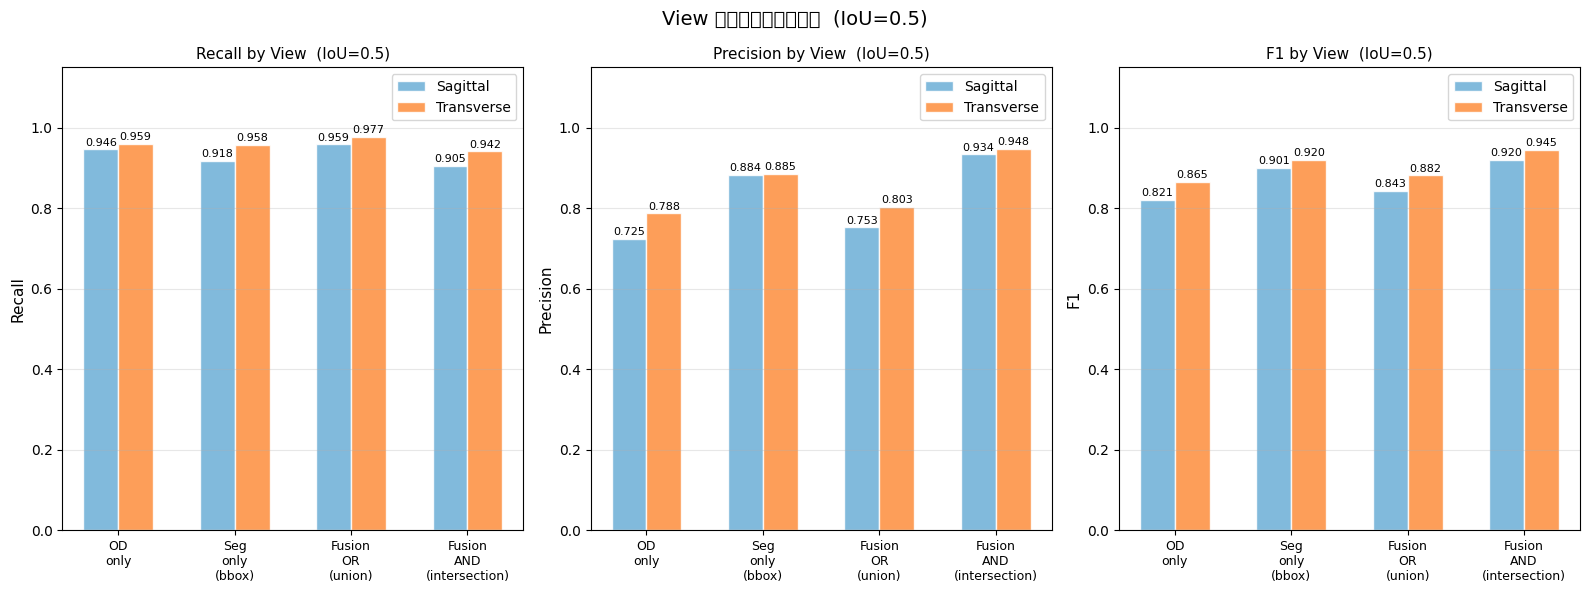

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:63: UserWarning: Glyph 36264 (\N{CJK UNIFIED IDEOGRAPH-8DA8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:63: UserWarning: Glyph 21218 (\N{CJK UNIFIED IDEOGRAPH-52E2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:63: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:63: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_65698/1875081452.py:63: UserWarning: Glyph 36328 (\N{CJK UNIFIED IDEOGRAPH-8DE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p

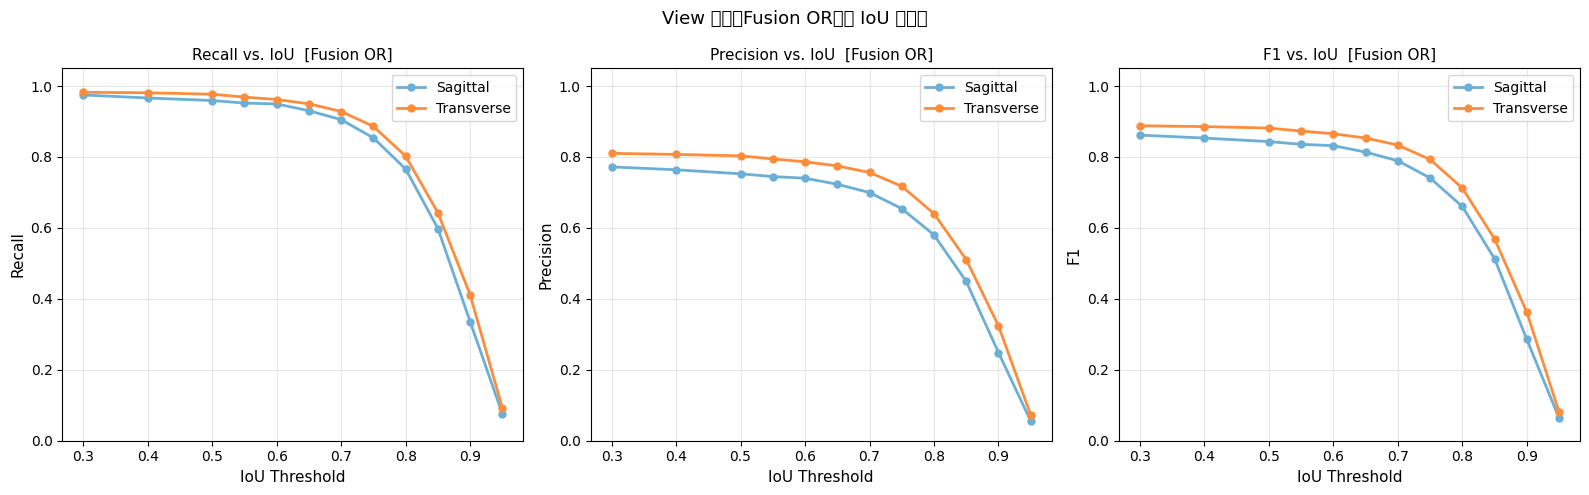

In [59]:
# ============================================================
# 視覺化：View × 策略 → Recall / Precision / F1
# ============================================================

metrics_v     = ['recall', 'precision', 'f1']
metric_titles_v = ['Recall', 'Precision', 'F1']
view_colors   = {'sagittal': '#6BAED6', 'transverse': '#FD8D3C'}

x_v = np.arange(len(strategies))
w_v = 0.3
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric, title in zip(axes, metrics_v, metric_titles_v):
    for vi, view in enumerate(VIEWS):
        vals = []
        for strategy in strategies:
            row = view_df[(view_df['strategy'] == strategy) & (view_df['view'] == view)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else np.nan)
        offset = (vi - 0.5) * w_v
        bars = ax.bar(x_v + offset, vals, w_v,
                      label=view.capitalize(),
                      color=view_colors[view], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x_v)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n') for s in strategies], fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by View  (IoU={VIEW_ANALYSIS_IOU})', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'View 對各策略效能之影響  (IoU={VIEW_ANALYSIS_IOU})', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 跨 IoU 閾值趨勢（以 OR 策略為例）----
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(axes2, metrics_v, metric_titles_v):
    for view in VIEWS:
        vals = []
        for iou_thr in all_iou_thresholds:
            df_iou = results_by_strategy_iou['or'][iou_thr].copy()
            df_iou['view'] = df_iou['file_name'].map(view_map)
            grp = df_iou[df_iou['view'] == view]
            tp = (grp['match_type'] == 'TP').sum()
            fp = (grp['match_type'] == 'FP').sum()
            fn = (grp['match_type'] == 'FN').sum()
            r, p, f = compute_metrics_from_counts(tp, fp, fn)
            vals.append({'recall': r, 'precision': p, 'f1': f}[metric])
        ax.plot(all_iou_thresholds, vals, marker='o', markersize=5,
                color=view_colors[view], linewidth=2, label=view.capitalize())
    ax.set_xlabel('IoU Threshold', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs. IoU  [Fusion OR]', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('View 趨勢（Fusion OR，跨 IoU 閾值）', fontsize=13)
plt.tight_layout()
plt.show()
